## 0. Imports

In [26]:
import os
os.environ["PYTHONWARNINGS"] = "ignore:pkg_resources is deprecated as an API:UserWarning"

import warnings
import random

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import brier_score_loss
from sklearn.pipeline import Pipeline
import quantstats as qs
import pandas as pd
import numpy as np

from src.helpers.model_matrix import align_and_fill_dates_across_tickers
from src.helpers.model_matrix import build_model_matrix_from_wrds
from src.helpers._extract import ensure_dir

warnings.filterwarnings(
    "ignore",
    message=r"pkg_resources is deprecated as an API\..*",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    message=r".*pkg_resources is deprecated as an API.*",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module=r"pkg_resources(\.|$)"
)

warnings.filterwarnings(
    "ignore",
    message="Mean of empty slice",
    category=RuntimeWarning,
)

## 1. Data build & cleaning (CRSP/DSF/IBES/FF)

In [27]:
tickers_list = [
    'AAPL', 'NVDA', 'MSFT', 'AMZN', 'TSLA',
     'GOOGL', 'LLY', 'WMT', 'JPM', 'BRK-B',
     #'V', 'MA', 'XOM', 'ORCL', 'UNH', 'COST', 'PG', 'HD', 'NFLX',
     #'JNJ', 'BAC', 'CRM', 'QQQ', 'ABBV', 'KO', 'CVX', 'TMUS', 'MRK', 'CSCO',
     #'WFC', 'ACN', 'NOW', 'TSM', 'AXP', 'PEP', 'MCD', 'IBM', 'MS', 'DIS',
     #'TMO', 'ABT', 'AMD', 'ADBE', 'PM', 'ISRG', 'GE', 'GS', 'INTU', 'CAT',
     #'TXN', 'QCOM', 'RY', 'VZ', 'DHR', 'BKNG', 'T', 'BLK', 'SPGI',
     #'RTX', 'PFE', 'NEE', 'HON', 'CMCSA', 'PGR', 'AMGN', 'LOW', 'ANET', 'UNP',
     #'SYK', 'TJX', 'C', 'BA', 'SCHW', 'BSX', 'KKR', 'ETN',
     #'COP', 'BX', 'PANW', 'ADP'
]

# will extract every possible ticker data (not just tickers_list) from wrds.
# the only wrds filters used are 'start' and 'end' dates.
# by extracting all possible ticker data, we can update tickers_list without
# connecting to wrds.
# the data are extracted from dsf, crsp, ff, and ibes (see src/migrations folder)
all_stocks = build_model_matrix_from_wrds(
    wrds_user="navid_namazi",
    start="2016-01-01",
    end="2021-01-01",
    chunk_size=500_000,
    tickers=tickers_list,
    use_run="last"  # "new", "last", or a specific folder name (i.e. "run_20250914_133747")
)

# ensure all stocks have the same date coverage
df = align_and_fill_dates_across_tickers(all_stocks=all_stocks)

[info] Using run folder: run_20251007_174249 (reuse=True)
[info] Reuse mode: all required Parquet files are present. No extraction performed.
{'run_folder': 'wrds_extracts\\run_20251007_174249', 'reuse': True, 'artifacts': {'dsf.parquet': 'wrds_extracts\\run_20251007_174249\\dsf.parquet', 'stocknames.parquet': 'wrds_extracts\\run_20251007_174249\\stocknames.parquet', 'ff.parquet': 'wrds_extracts\\run_20251007_174249\\ff.parquet', 'ibes_stats.parquet': 'wrds_extracts\\run_20251007_174249\\ibes_stats.parquet', 'ibes_act.parquet': 'wrds_extracts\\run_20251007_174249\\ibes_act.parquet'}}


[info] Removed 0 permnos(companies) for having zero in cfacpr or cfacshr
[info] Removed 0 permnos(companies) for exceeding the threshold of negative prices
$$$$ df_prices initial shape :  (11331, 18)
[info] ibes_stats: 274,942 (official_ticker, stat_date) pairs have >1 row (multiple horizons/periodicities). Will collapse before join.
[info] df_prices(+ibes): 95.2% missing in n_analysts.
[info] df_prices(+ibes): 95.2% missing in cons_mean.
[info] df_prices(+ibes): 95.5% missing in cons_stdev.
[info] df_prices(+ibes): 95.5% missing in cons_cv.
[info] ibes_act: 218 (oftic, anndats) pairs have >1 row (periodicity/dup loads). Will collapse before join.
[info] df_prices(+ibes_act): 98.8% missing in act_value.
[info] ibes_act announcement time top values:
anntims
16:01:00    18
16:20:00    17
16:30:00    16
06:25:00    15
16:05:00     9
Name: count, dtype: int64
removed these columns manually:  ['numtrd', 'pdicity', 'act_measure', 'act_value', 'curr_act', 'anntims', 'actdats', 'acttims', 'pen

## 2. Train/test split & rolling CV split

In [28]:
from src.helpers.split_window import split_train_and_test
# Execute the split
random_state = 42
split_pct = 0.80
ins_dates, dates_out_sample, split_date = split_train_and_test(df, split_pct, random_state)

Total Data:
  Dates: 1189 trading days
  Period: 2016-04-14 to 2020-12-31
  Rows: 10,701 (stocks × dates)

Data Split:
   In-Sample (Development Set):
   Period: 2016-04-14 to 2020-01-23
   Dates: 951 days (80.0%)
   Purpose: feature selection, hyperparameter tuning, rolling CV

Out-Of-Sample (Test Set):
   Period: 2020-01-24 to 2020-12-31
   Dates: 238 days (20.0%)
   Purpose: final performance evaluation only

Split Date: 2020-01-24


In [29]:
from src.helpers.split_window import split_rolling_window

# Rolling window size configuration for in-sample (60/20/20 Split)
# When naming variables, ins short for in-sample, oos short for out-of-sample 

# Configure rolling windows
split_pct_rolling_train = 0.6  # 60% for training
split_pct_rolling_test = 0.2   # 20% for validation
target_folds_count = 10

ins_window_size, ins_training_window_size, ins_validation_window_size, step_size, actual_folds = split_rolling_window(
    ins_dates, 
    split_pct_rolling_train=split_pct_rolling_train,
    split_pct_rolling_test=split_pct_rolling_test,
    target_folds_count=target_folds_count
)

Rolling Window Configuration (In-Sample Only):
   Training window: 570 days (~2.3 years, 59.9% of in-sample)
   Validation window: 190 days (~0.8 years, 20.0% of in-sample)
   Step size: 21 days (~4.2 weeks)
   Target folds: 10
   Actual folds: 10
   Total validation observations: 1900 (across 10 overlapping folds)


## 3. Logistic Regression (Direction)

### 3.1. Configuration

In [30]:
# Binary Target Definition
print("Target Column: adj_prc_logret_lead1 = next-day log return(t -> t+1)")
print("We predict: will the stock go up (1) or down (0) tomorrow?")

DIR_binary = (df["adj_prc_logret_lead1"] > 0).astype(int)  # 1 = up, 0 = down

# check class balance (market neutrality ~ 50/50)
print("\nBinary Target Distribution")
print(f" Up (1):   {(DIR_binary == 1).sum():,} observations ({(DIR_binary == 1).mean() * 100:.1f}%)")  # noqa
print(f" Down (0): {(DIR_binary == 0).sum():,} observations ({(DIR_binary == 0).mean() * 100:.1f}%)")  # noqa
print(f" Total:    {len(DIR_binary):,} observations")

# feature columns: everything except ticker, target, and the index columns, permno and date.
num_pred_cols = [c for c in df.columns if c not in (["ticker", "adj_prc_logret_lead1"])]
print(f"\nUsing {len(num_pred_cols)} features for prediction")

Target Column: adj_prc_logret_lead1 = next-day log return(t -> t+1)
We predict: will the stock go up (1) or down (0) tomorrow?

Binary Target Distribution
 Up (1):   5,743 observations (53.7%)
 Down (0): 4,958 observations (46.3%)
 Total:    10,701 observations

Using 102 features for prediction


### 3.2. Hyperparameter tuning: logistic regression + ElasticNet

In [ ]:
print("ElasticNet Hyperparameters and Pipeline Configuration")
# HYPERPARAMETER TUNING CONFIGURATION
# Toggle between hardcoded hyperparameters (fast) and grid search tuning (slow)
TUNE_HYPERPARAMETERS = False  # Set to True to enable full grid search, False for hardcoded values

# Hardcoded hyperparameters (used when TUNE_HYPERPARAMETERS = False)
ELASTICNET_C = 0.1  # Inverse of regularization strength (higher C means less regularization, lower C means more regularization).
ELASTICNET_L1_RATIO = 0.7  # Controls the L1/L2 tradeoff (0 is ridge, 1 is lasso, anything in between mixes the two)

# Grid search ranges (used when TUNE_HYPERPARAMETERS = True)
# common grid search for l1_ratio : [0, 0.25, 0.5, 0.75, 1.0]  and for C: [0.01, 0.1, 1, 10, 100]
param_grid = {
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__l1_ratio": [0.3, 0.5, 0.7],
}

print(f"\n🔧 Hyperparameter Tuning Mode: {'ENABLED (Grid Search)' if TUNE_HYPERPARAMETERS else 'DISABLED (Hardcoded)'}")
print(f"\nDefault/Hardcoded Hyperparameters:")
print(f"  C: {ELASTICNET_C}")
print(f"  l1_ratio: {ELASTICNET_L1_RATIO}")

if TUNE_HYPERPARAMETERS:
    print(f"\n Grid Search will explore:")
    print(f"  C: {param_grid['clf__C']}")
    print(f"  l1_ratio: {param_grid['clf__l1_ratio']}")

# Preprocessing: Standardize features
ct = ColumnTransformer([(
    "num",  # numerical
    # scales each feature so ElasticNet penalty treats them similarly (to avoid leakage).
    # scaling is done per fold-by-fold
    StandardScaler(with_mean=True),
    num_pred_cols  # only numerical columns
)],
    remainder="drop",  # columns not listed are dropped
    sparse_threshold=0.0  # force dense for feature importance
)

# Classifier with ElasticNet regularization
clf = LogisticRegression(
    penalty="elasticnet",  # Use ElasticNet (L1 + L2)
    solver="saga",  # Only solver supporting elasticnet
    l1_ratio=ELASTICNET_L1_RATIO,  # Mix of L1 and L2
    C=ELASTICNET_C,  # Regularization strength
    max_iter=5000,  # More iterations for convergence
    tol=1e-4,
    random_state=random_state,
    n_jobs=-1  # Use all CPUs
)

# Pipeline: preprocessing to classification
pipe = Pipeline([("prep", ct), ("clf", clf)])

ElasticNet Hyperparameters and Pipeline Configuration

🔧 Hyperparameter Tuning Mode: DISABLED (Hardcoded)

Default/Hardcoded Hyperparameters:
  C: 0.1
  l1_ratio: 0.7

Pipeline Flow:
   1) 'prep' = ColumnTransformer(ct): standardize features (fit on train only to avoid leakage
   2) 'clf'  = LogisticRegression with ElasticNet: learns β per fold


### 3.3. Rolling training & feature selection per fold (Model Selection and Cross-Validation)

In [32]:
print("Rolling Window Training With Feature Selection (In-Sample Only)")

pred_prob_up_new = pd.Series(index=df.index, dtype=float)
pred_prob_down_new = pd.Series(index=df.index, dtype=float)
pred_score_new = pd.Series(index=df.index, dtype=float)
pred_class_new = pd.Series(index=df.index, dtype=int)
used_mask_new = pd.Series(False, index=df.index)

# track feature selection across windows
feature_selection_history = []

window_num = 0
start_pos = 0

while start_pos + ins_training_window_size + ins_validation_window_size <= len(ins_dates):
    window_num += 1

    train_dates = ins_dates[start_pos: start_pos + ins_training_window_size]
    valid_dates = ins_dates[
                  start_pos + ins_training_window_size: start_pos + ins_training_window_size + ins_validation_window_size]

    print(f"\nWindow {window_num}: {train_dates.min().date()} to {valid_dates.max().date()}")

    start_pos += step_size

    idx_tr = df.index.get_level_values("date").isin(train_dates)
    idx_va = df.index.get_level_values("date").isin(valid_dates)

    X_tr = df.loc[idx_tr, num_pred_cols]
    y_tr = DIR_binary.loc[idx_tr]
    X_va = df.loc[idx_va, num_pred_cols]
    y_va = DIR_binary.loc[idx_va]
    groups_ins = X_tr.index.get_level_values("date")
    
    # Conditional hyperparameter tuning based on TUNE_HYPERPARAMETERS flag
    if TUNE_HYPERPARAMETERS:
        # Full grid search with cross-validation (slower)
        gs = GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            scoring="neg_brier_score",  # maximize -Brier == minimize Brier
            cv=GroupKFold(n_splits=3),
            n_jobs=-1,
            refit=True  # refit on the whole training set with best params at the end of grid search and CV
        )
        gs.fit(X_tr, y_tr, groups=groups_ins)
        pipe_best = gs.best_estimator_
        best_C = gs.best_params_['clf__C']
        best_l1 = gs.best_params_['clf__l1_ratio']
        cv_score = gs.best_score_
    else:
        # Use hardcoded hyperparameters (faster)
        pipe_best = pipe
        pipe_best.fit(X_tr, y_tr)
        best_C = ELASTICNET_C
        best_l1 = ELASTICNET_L1_RATIO
        cv_score = None  # No CV score when not tuning

    # validation RMSE report (probability RMSE = sqrt(Brier))
    p_up_val = pipe_best.predict_proba(X_va)[:, 1]
    rmse_val = np.sqrt(brier_score_loss(y_va, p_up_val))
    print(f"   Best params: C={best_C}, l1={best_l1}")
    print(f"   Validation RMSE (proba): {rmse_val:.4f}")
    if cv_score is not None:
        print(f"   train(CV) RMSE (proba): {np.sqrt(np.sqrt(-cv_score)):.4f}")

    # feature Selection Analysis (from tuned model)
    coef = pipe_best.named_steps["clf"].coef_[0]

    feature_importance = pd.DataFrame({
        "feature": num_pred_cols,
        "coefficient": coef,
        "abs_coefficient": np.abs(coef)
    })

    ZERO_THRESHOLD = 1e-5
    selected_features = feature_importance[feature_importance["abs_coefficient"] > ZERO_THRESHOLD]
    n_selected = len(selected_features)
    pct_selected = (n_selected / len(num_pred_cols)) * 100

    top_features = selected_features.nlargest(10, "abs_coefficient")

    feature_selection_history.append({
        "window": window_num,
        "n_features_selected": n_selected,
        "pct_selected": pct_selected,
        "selected_features": selected_features["feature"].tolist(),
        "top_5_features": top_features.head(5)["feature"].tolist(),
        "train_start": train_dates.min(),
        "valid_end": valid_dates.max()
    })

    # predictions from the tuned model
    proba = pipe_best.predict_proba(X_va)
    p_down = proba[:, 0]
    p_up = proba[:, 1]
    score = 2 * p_up - 1
    yhat = (p_up > 0.5).astype(int)

    # store predictions
    pred_prob_up_new.loc[idx_va] = p_up
    pred_prob_down_new.loc[idx_va] = p_down
    pred_score_new.loc[idx_va] = score
    pred_class_new.loc[idx_va] = yhat
    used_mask_new.loc[idx_va] = True

    # report
    accuracy = (yhat == y_va).mean()  # noqa

    # High-confidence accuracy: only count predictions where p_up > 0.55 or p_up < 0.45
    high_conf_mask = (p_up > 0.55) | (p_up < 0.45)
    high_conf_accuracy = (yhat[high_conf_mask] == y_va.values[high_conf_mask]).mean()
    n_high_conf = high_conf_mask.sum()
    print(f"Training: {len(X_tr):,} samples")
    print(f"Validation: {len(X_va):,} samples, Accuracy: {accuracy:.1%}")
    print(f"High-confidence accuracy (p_up > 0.55) or (p_up < 0.45): {high_conf_accuracy:.1%} on {n_high_conf} samples")
    print("\nFeature Selection:")
    print(f"   Selected: {n_selected}/{len(num_pred_cols)} features ({pct_selected:.1f}%)")
    print("   Top 5 features by importance:")
    for i, row in top_features.head(5).iterrows():
        print(f"      {i + 1}. {row['feature']}: {row['coefficient']:+.4f}")

print(f"\nTraining complete: {window_num} windows processed")
print(f"Total validated: {used_mask_new.sum():,} / {len(df):,}")

# update global predictions with new ones
pred_prob_up = pred_prob_up_new
pred_prob_down = pred_prob_down_new
pred_score = pred_score_new
pred_class = pred_class_new
used_mask = used_mask_new

Rolling Window Training With Feature Selection (In-Sample Only)

Window 1: 2016-04-14 to 2019-04-22


   Best params: C=0.1, l1=0.7
   Validation RMSE (proba): 0.5412
Training: 5,130 samples
Validation: 1,710 samples, Accuracy: 45.6%
High-confidence accuracy (p_up > 0.55) or (p_up < 0.45): 44.1% on 1319 samples

Feature Selection:
   Selected: 75/102 features (73.5%)
   Top 5 features by importance:
      76. comm_ti_^VIX_atr_14: -0.2305
      7. comm_XLK_close_logret: -0.1854
      38. ratio_volatility_premium_lag1: -0.1838
      13. comm_^VXN_close_logret: -0.1652
      26. comm_^RUT_close_logret_lag5: +0.1627

Window 2: 2016-05-13 to 2019-05-21
   Best params: C=0.1, l1=0.7
   Validation RMSE (proba): 0.5307
Training: 5,130 samples
Validation: 1,710 samples, Accuracy: 46.9%
High-confidence accuracy (p_up > 0.55) or (p_up < 0.45): 46.6% on 1382 samples

Feature Selection:
   Selected: 73/102 features (71.6%)
   Top 5 features by importance:
      38. ratio_volatility_premium_lag1: -0.2196
      25. comm_^RUT_close_logret_lag1: +0.1616
      76. comm_ti_^VIX_atr_14: -0.1595
      13. 

### 3.4. Feature selection across all folds

In [33]:
print("Feature Selection For Final Model")

# extract selection information from all windows
n_windows = len(feature_selection_history)
feature_counts = {feat: 0 for feat in num_pred_cols}

# count how many windows each feature was selected in
for window_info in feature_selection_history:
    selected_features = window_info["selected_features"]
    for feat in selected_features:
        feature_counts[feat] += 1

# calculate frequency (percentage of windows)
feature_freq = pd.DataFrame({
    "feature": list(feature_counts.keys()),
    "count": list(feature_counts.values()),
    "frequency": [count / n_windows for count in feature_counts.values()]
}).sort_values("frequency", ascending=False)

SELECTION_THRESHOLD = 0.5  # Features must appear in at least 50% of rolling windows

selected_features_mask = feature_freq["frequency"] >= SELECTION_THRESHOLD
final_feature_list = feature_freq.loc[selected_features_mask, "feature"].tolist()

print("\n  Selection Criterion:")
print(f"   Frequency threshold: ≥ {SELECTION_THRESHOLD * 100:.0f}% of windows")
print("   Rationale: Features must be consistently predictive across")
print("              different market regimes to be included")

print("\n  Results:")
print(f"   Features selected: {len(final_feature_list)} / {len(num_pred_cols)}")
print(f"   Features removed:  {len(num_pred_cols) - len(final_feature_list)}")
print(f"   Reduction: {(1 - len(final_feature_list) / len(num_pred_cols)) * 100:.1f}%")

# display selected features
print(f"\n  Selected Features ({len(final_feature_list)}):")
print(f"    {'Feature':<30} {'Frequency':<12}     {'Appearances':<15}")

selected_features_df = feature_freq[selected_features_mask].copy()
for idx, row in selected_features_df.iterrows():
    feat = row['feature']
    freq = row['frequency']
    count = row['count']
    bar = '█' * int(freq * 10)
    print(f"    {feat:<30} {freq:>6.1%} ({count:>2}/{n_windows})   {bar}")

# display removed features
removed_features_df = feature_freq[~selected_features_mask].copy()

if len(removed_features_df) > 0:
    print(f"\n  Removed Features ({len(removed_features_df)}):")
    print(f"    {'Feature':<30} {'Frequency':<12}     {'Appearances':<15}")

    for idx, row in removed_features_df.iterrows():
        feat = row['feature']
        freq = row['frequency']
        count = row['count']
        bar = '░' * int(freq * 10)
        print(f"    {feat:<30} {freq:>6.1%} ({count:>2}/{n_windows})   {bar}")


# feature categories breakdown
def categorize_feature(feat):
    """Categorize feature by type"""
    if feat.startswith("ti_"):
        return "Technical Indicator applied to ticker"
    if feat.startswith("comm_"):
        if "ti_" in feat:
            return "Technical Indicator applied to common feature"
        else:
            return "Common feature"
    if feat.startswith("ti_"):
        return "Technical Indicator applied to ticker"
    elif feat in ["mktrf", "smb", "hml", "rf", "umd"]:
        return "Fama-French Factors"
    elif feat.startswith("cons_") or feat.startswith("n_"):
        return "IBES Consensus"
    elif feat.startswith("adjclose_lag"):
        return "Price Lags"
    elif feat in ["adj_mktcap", "vol", "retx"]:
        return "Market Data"
    else:
        return "Other"


selected_features_df["category"] = selected_features_df["feature"].apply(categorize_feature)
category_counts = selected_features_df["category"].value_counts()

print("\n  Selected Features By Category:")

for category, count in category_counts.items():
    pct = count / len(selected_features_df) * 100
    print(f"    {category:<30} {count:>2} features ({pct:>5.1f}%)")

Feature Selection For Final Model

  Selection Criterion:
   Frequency threshold: ≥ 50% of windows
   Rationale: Features must be consistently predictive across
              different market regimes to be included

  Results:
   Features selected: 78 / 102
   Features removed:  24
   Reduction: 23.5%

  Selected Features (78):
    Feature                        Frequency        Appearances    
    adj_prc_logret                 100.0% (10/10)   ██████████
    adj_prc_logret_lag4            100.0% (10/10)   ██████████
    adj_prc_logret_lag1            100.0% (10/10)   ██████████
    adj_prc_logret_lag2            100.0% (10/10)   ██████████
    adj_prc_logret_lag5            100.0% (10/10)   ██████████
    comm_^VXN_close_logret         100.0% (10/10)   ██████████
    comm_XLF_close_logret_lag1     100.0% (10/10)   ██████████
    ratio_volatility_premium_lag1  100.0% (10/10)   ██████████
    comm_XLI_close_logret_lag1     100.0% (10/10)   ██████████
    comm_^RUT_close_logret_lag5    

### 3.5. Train the final in-sample model on all in-sample data

In [34]:
# hyperparameter selection on all in-sample

print("\nGlobal Hyperparameter Search (in-sample, using selected features)")

# build in-sample slice with final features
ins_mask = df.index.get_level_values("date").isin(ins_dates)
X_ins = df.loc[ins_mask, final_feature_list]
y_ins = DIR_binary.loc[ins_mask]

# group by date so folds split by day (avoid same-day leakage across stocks)
groups_ins = df.loc[ins_mask].index.get_level_values("date")


# rebuild pipeline constrained to the selected features
ct_final_cv = ColumnTransformer(
    [("num", StandardScaler(with_mean=True), final_feature_list)],
    remainder="drop",
    sparse_threshold=0.0
)
clf_final_cv = LogisticRegression(
    penalty="elasticnet",
    solver="saga",
    max_iter=5000,
    tol=1e-4,
    random_state=random_state,
    n_jobs=-1
)
pipe_final_cv = Pipeline([("prep", ct_final_cv), ("clf", clf_final_cv)])

# Conditional global hyperparameter tuning based on TUNE_HYPERPARAMETERS flag
if TUNE_HYPERPARAMETERS:
    # Full grid search with cross-validation (slower)
    param_grid_global = {
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__l1_ratio": [0.3, 0.5, 0.7],
    }
    
    # time-aware CV via GroupKFold over dates
    cv_global = GroupKFold(n_splits=5)
    gs_global = GridSearchCV(
        estimator=pipe_final_cv,
        param_grid=param_grid_global,
        scoring="neg_brier_score",  # minimize Brier (probability RMSE)
        cv=cv_global,
        n_jobs=-1,
        refit=True
    )
    gs_global.fit(X_ins, y_ins, groups=groups_ins)
    
    best_C = gs_global.best_params_["clf__C"]
    best_l1 = gs_global.best_params_["clf__l1_ratio"]
    print(f"Best global params: C={best_C}, l1_ratio={best_l1}")
    print(f"Best mean CV Brier: {-gs_global.best_score_:.6f} (RMSE={(-gs_global.best_score_) ** 0.5:.4f})")
else:
    # Use hardcoded hyperparameters (faster)
    best_C = ELASTICNET_C
    best_l1 = ELASTICNET_L1_RATIO
    print(f"Using hardcoded params: C={best_C}, l1_ratio={best_l1}")

# lock in the global best hyperparameters and train final in-sample model
clf_final = LogisticRegression(
    penalty="elasticnet",
    solver="saga",
    C=best_C,
    l1_ratio=best_l1,
    max_iter=5000,
    tol=1e-4,
    random_state=random_state,
    n_jobs=-1
)
ct_final = ColumnTransformer(
    [("num", StandardScaler(with_mean=True), final_feature_list)],
    remainder="drop",
    sparse_threshold=0.0
)
pipe_final = Pipeline([("prep", ct_final), ("clf", clf_final)])
pipe_final.fit(X_ins, y_ins)

# report sparsity of the final model
final_coef = pipe_final.named_steps["clf"].coef_[0]
print(f"Final model non-zero coeffs: {(np.abs(final_coef) > 1e-5).sum()} / {len(final_coef)}")


Global Hyperparameter Search (in-sample, using selected features)
Using hardcoded params: C=0.1, l1_ratio=0.7


Final model non-zero coeffs: 65 / 78


## 4. Linear Regression (Magnitude)

### 4.1. Configuration

In [35]:
# Continuous Target Definition for Linear Regression
print("Target Column: adj_prc_logret_lead1 = next-day log return(t -> t+1)")
print("We predict: the MAGNITUDE of tomorrow's return (continuous value)")

# Continuous target (actual log returns, not binarized)
y_continuous = df["adj_prc_logret_lead1"]

# Check distribution statistics
print("\nContinuous Target Distribution (Expected Returns)")
print(f"  Mean:        {y_continuous.mean():.6f}")
print(f"  Std Dev:     {y_continuous.std():.6f}")
print(f"  Min:         {y_continuous.min():.6f}")
print(f"  Max:         {y_continuous.max():.6f}")
print(f"  Median:      {y_continuous.median():.6f}")
print(f"  Total:       {len(y_continuous):,} observations")

# Distribution percentiles
print("\nPercentiles:")
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
for p in percentiles:
    val = y_continuous.quantile(p / 100)
    print(f"  {p:>2}th:  {val:>10.6f}")

# Positive vs Negative returns (for context)
n_positive = (y_continuous > 0).sum()
n_negative = (y_continuous < 0).sum()
n_zero = (y_continuous == 0).sum()
print(f"\nDirection Split (for reference):")
print(f"  Positive returns: {n_positive:>5,} ({n_positive/len(y_continuous)*100:>5.1f}%)")
print(f"  Negative returns: {n_negative:>5,} ({n_negative/len(y_continuous)*100:>5.1f}%)")
print(f"  Zero returns:     {n_zero:>5,} ({n_zero/len(y_continuous)*100:>5.1f}%)")

# Confirm we're using the same feature set
print(f"\nUsing {len(num_pred_cols)} features for prediction (same as logistic regression)")


Target Column: adj_prc_logret_lead1 = next-day log return(t -> t+1)
We predict: the MAGNITUDE of tomorrow's return (continuous value)

Continuous Target Distribution (Expected Returns)
  Mean:        0.000654
  Std Dev:     0.045673
  Min:         -3.100480
  Max:         0.260876
  Median:      0.001098
  Total:       10,701 observations

Percentiles:
   1th:   -0.063688
   5th:   -0.030224
  10th:   -0.019431
  25th:   -0.006997
  50th:    0.001098
  75th:    0.009883
  90th:    0.020873
  95th:    0.031313
  99th:    0.066427

Direction Split (for reference):
  Positive returns: 5,743 ( 53.7%)
  Negative returns: 4,922 ( 46.0%)
  Zero returns:        36 (  0.3%)

Using 102 features for prediction (same as logistic regression)


### 4.2. Hyperparameter tuning: linear regression + ElasticNet


In [36]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

print("=" * 80)
print("LINEAR REGRESSION MODEL: Expected Return Prediction")
print("=" * 80)

print("\n📈 Objective: Predict the magnitude of next-day returns (not just direction)")
print("   Target: adj_prc_logret_lead1 (continuous)")
print("   Purpose: Complement logistic regression for ensemble filtering\n")

# Linear regression will use ElasticNet (L1 + L2 regularization)
# Same regularization approach as logistic regression
# Use same hyperparameter tuning toggle as logistic regression

print("Linear Regression Hyperparameters and Pipeline Configuration")
print(f"\n🔧 Hyperparameter Tuning Mode: {'ENABLED (Grid Search)' if TUNE_HYPERPARAMETERS else 'DISABLED (Hardcoded)'}")

# Hardcoded hyperparameters for linear regression (ElasticNet)
# Note: For regression, alpha needs to be much smaller than for classification
# to avoid driving all coefficients to zero
LINEAR_ALPHA = 0.001  # ElasticNet regularization strength (higher = more regularization)
LINEAR_L1_RATIO = 0.5  # Mix of L1 and L2 (0=Ridge, 1=Lasso, 0.5=equal mix)

print(f"\nDefault/Hardcoded Hyperparameters:")
print(f"  alpha: {LINEAR_ALPHA}")
print(f"  l1_ratio: {LINEAR_L1_RATIO}")

# Grid search ranges (used when TUNE_HYPERPARAMETERS = True)
# Adjusted for regression problem - smaller alphas to avoid over-regularization
param_grid_linear = {
    "clf__alpha": [0.0001, 0.001, 0.01, 0.1],
    "clf__l1_ratio": [0.3, 0.5, 0.7, 0.9],
}

if TUNE_HYPERPARAMETERS:
    print(f"\n📊 Grid Search will explore:")
    print(f"  alpha: {param_grid_linear['clf__alpha']}")
    print(f"  l1_ratio: {param_grid_linear['clf__l1_ratio']}")

# Preprocessing: Standardize features (same as logistic)
ct_linear = ColumnTransformer([
    ("num", StandardScaler(with_mean=True), num_pred_cols)
], remainder="drop", sparse_threshold=0.0)

# ElasticNet regression with L1 + L2 regularization
clf_linear = ElasticNet(
    alpha=LINEAR_ALPHA,
    l1_ratio=LINEAR_L1_RATIO,
    max_iter=5000,
    tol=1e-4,
    random_state=random_state
)

# Pipeline: preprocessing to regression
pipe_linear = Pipeline([("prep", ct_linear), ("clf", clf_linear)])

print("\nPipeline Flow:")
print("   1) 'prep' = ColumnTransformer: standardize features")
print("   2) 'clf'  = ElasticNet Regression: predicts E[R] for t+1")


LINEAR REGRESSION MODEL: Expected Return Prediction

📈 Objective: Predict the magnitude of next-day returns (not just direction)
   Target: adj_prc_logret_lead1 (continuous)
   Purpose: Complement logistic regression for ensemble filtering

Linear Regression Hyperparameters and Pipeline Configuration

🔧 Hyperparameter Tuning Mode: DISABLED (Hardcoded)

Default/Hardcoded Hyperparameters:
  alpha: 0.001
  l1_ratio: 0.5

Pipeline Flow:
   1) 'prep' = ColumnTransformer: standardize features
   2) 'clf'  = ElasticNet Regression: predicts E[R] for t+1


### 4.3. Rolling training & feature selection per fold (Model Selection and Cross-Validation)

In [37]:
import time
from sklearn.base import clone

print("Rolling Window Training for Linear Regression (In-Sample Only)")
print("Using the SAME rolling windows as logistic regression")
print(f"Mode: {'GRID SEARCH' if TUNE_HYPERPARAMETERS else 'HARDCODED HYPERPARAMETERS (FAST)'}")
print(f"Hyperparameters: alpha={LINEAR_ALPHA}, l1_ratio={LINEAR_L1_RATIO}")
print("Note: If all features = 0, alpha is too high (decrease by 10x)\n")

pred_return_linear = pd.Series(index=df.index, dtype=float)
used_mask_linear = pd.Series(False, index=df.index)

# track feature selection across windows
feature_selection_history_linear = []

window_num = 0
start_pos = 0

while start_pos + ins_training_window_size + ins_validation_window_size <= len(ins_dates):
    window_num += 1
    window_start_time = time.time()

    train_dates = ins_dates[start_pos: start_pos + ins_training_window_size]
    valid_dates = ins_dates[
                  start_pos + ins_training_window_size: start_pos + ins_training_window_size + ins_validation_window_size]

    print(f"\n{'='*70}")
    print(f"Window {window_num}: {train_dates.min().date()} to {valid_dates.max().date()}")

    start_pos += step_size

    idx_tr = df.index.get_level_values("date").isin(train_dates)
    idx_va = df.index.get_level_values("date").isin(valid_dates)

    X_tr = df.loc[idx_tr, num_pred_cols]
    y_tr = y_continuous.loc[idx_tr]
    X_va = df.loc[idx_va, num_pred_cols]
    y_va = y_continuous.loc[idx_va]
    groups_ins = X_tr.index.get_level_values("date")
    
    print(f"Training samples: {len(X_tr):,} | Validation samples: {len(X_va):,}")
    
    # Conditional hyperparameter tuning based on TUNE_HYPERPARAMETERS flag
    fit_start_time = time.time()
    if TUNE_HYPERPARAMETERS:
        print("⚙️  Running GRID SEARCH with cross-validation...")
        # Full grid search with cross-validation (slower)
        gs_linear = GridSearchCV(
            estimator=pipe_linear,
            param_grid=param_grid_linear,
            scoring="neg_mean_squared_error",  # maximize -MSE == minimize MSE
            cv=GroupKFold(n_splits=3),
            n_jobs=-1,
            refit=True
        )
        gs_linear.fit(X_tr, y_tr, groups=groups_ins)
        pipe_best_linear = gs_linear.best_estimator_
        best_alpha = gs_linear.best_params_['clf__alpha']
        best_l1_ratio = gs_linear.best_params_['clf__l1_ratio']
        cv_score = gs_linear.best_score_
    else:
        print("⚡ Using HARDCODED hyperparameters (no grid search)...")
        # Use hardcoded hyperparameters (faster) - create fresh clone
        pipe_best_linear = clone(pipe_linear)
        pipe_best_linear.fit(X_tr, y_tr)
        best_alpha = LINEAR_ALPHA
        best_l1_ratio = LINEAR_L1_RATIO
        cv_score = None
    
    fit_time = time.time() - fit_start_time
    print(f"   Fitting time: {fit_time:.2f} seconds")

    # validation RMSE report
    y_pred_val = pipe_best_linear.predict(X_va)
    rmse_val = np.sqrt(mean_squared_error(y_va, y_pred_val))
    r2_val = r2_score(y_va, y_pred_val)
    
    print(f"   Best params: alpha={best_alpha}, l1_ratio={best_l1_ratio}")
    print(f"   Validation RMSE: {rmse_val:.6f}")
    print(f"   Validation R²: {r2_val:.4f}")
    if cv_score is not None:
        print(f"   train(CV) RMSE: {np.sqrt(-cv_score):.6f}")

    # feature Selection Analysis (from tuned model)
    coef = pipe_best_linear.named_steps["clf"].coef_

    feature_importance = pd.DataFrame({
        "feature": num_pred_cols,
        "coefficient": coef,
        "abs_coefficient": np.abs(coef)
    })

    ZERO_THRESHOLD = 1e-5
    selected_features = feature_importance[feature_importance["abs_coefficient"] > ZERO_THRESHOLD]
    n_selected = len(selected_features)
    pct_selected = (n_selected / len(num_pred_cols)) * 100

    top_features = selected_features.nlargest(10, "abs_coefficient")

    feature_selection_history_linear.append({
        "window": window_num,
        "n_features_selected": n_selected,
        "pct_selected": pct_selected,
        "selected_features": selected_features["feature"].tolist(),
        "top_5_features": top_features.head(5)["feature"].tolist(),
        "train_start": train_dates.min(),
        "valid_end": valid_dates.max()
    })

    # store predictions
    pred_return_linear.loc[idx_va] = y_pred_val
    used_mask_linear.loc[idx_va] = True

    # report
    print(f"\nFeature Selection:")
    print(f"   Selected: {n_selected}/{len(num_pred_cols)} features ({pct_selected:.1f}%)")
    print("   Top 5 features by importance:")
    for i, row in top_features.head(5).iterrows():
        print(f"      {i + 1}. {row['feature']}: {row['coefficient']:+.6f}")
    
    window_time = time.time() - window_start_time
    print(f"\n⏱️  Window {window_num} total time: {window_time:.2f} seconds ({window_time/60:.2f} minutes)")

print(f"\nLinear Regression Training complete: {window_num} windows processed")
print(f"Total validated: {used_mask_linear.sum():,} / {len(df):,}")


Rolling Window Training for Linear Regression (In-Sample Only)
Using the SAME rolling windows as logistic regression
Mode: HARDCODED HYPERPARAMETERS (FAST)
Hyperparameters: alpha=0.001, l1_ratio=0.5
Note: If all features = 0, alpha is too high (decrease by 10x)


Window 1: 2016-04-14 to 2019-04-22
Training samples: 5,130 | Validation samples: 1,710
⚡ Using HARDCODED hyperparameters (no grid search)...
   Fitting time: 0.09 seconds
   Best params: alpha=0.001, l1_ratio=0.5
   Validation RMSE: 0.023414
   Validation R²: -0.0012

Feature Selection:
   Selected: 14/102 features (13.7%)
   Top 5 features by importance:
      97. comm_ti_^GSPC_eom_14: -0.000390
      101. comm_ti_^GSPC_kurtosis_63: +0.000265
      21. comm_^GSPC_close_logret_lag1: -0.000242
      82. comm_ti_^VIX_psar_acc: -0.000237
      8. comm_XLF_close_logret: -0.000232

⏱️  Window 1 total time: 0.15 seconds (0.00 minutes)

Window 2: 2016-05-13 to 2019-05-21
Training samples: 5,130 | Validation samples: 1,710
⚡ Using HAR


⚡ Using HARDCODED hyperparameters (no grid search)...
   Fitting time: 0.07 seconds
   Best params: alpha=0.001, l1_ratio=0.5
   Validation RMSE: 0.017810
   Validation R²: 0.0023

Feature Selection:
   Selected: 14/102 features (13.7%)
   Top 5 features by importance:
      101. comm_ti_^GSPC_kurtosis_63: +0.000749
      93. comm_ti_^GSPC_mfi_14: -0.000566
      36. ratio_XLV_^GSPC_lag1: -0.000437
      57. hml: -0.000348
      1. adj_prc_logret: -0.000337

⏱️  Window 7 total time: 0.20 seconds (0.00 minutes)

Window 8: 2016-11-10 to 2019-11-18
Training samples: 5,130 | Validation samples: 1,710
⚡ Using HARDCODED hyperparameters (no grid search)...
   Fitting time: 0.13 seconds
   Best params: alpha=0.001, l1_ratio=0.5
   Validation RMSE: 0.017458
   Validation R²: -0.0023

Feature Selection:
   Selected: 15/102 features (14.7%)
   Top 5 features by importance:
      93. comm_ti_^GSPC_mfi_14: -0.000778
      101. comm_ti_^GSPC_kurtosis_63: +0.000740
      1. adj_prc_logret: -0.000342

### 4.4. Feature selection across all folds

In [38]:
print("Feature Selection For Linear Regression Model")

# extract selection information from all windows
n_windows_linear = len(feature_selection_history_linear)
feature_counts_linear = {feat: 0 for feat in num_pred_cols}

# count how many windows each feature was selected in
for window_info in feature_selection_history_linear:
    selected_features = window_info["selected_features"]
    for feat in selected_features:
        feature_counts_linear[feat] += 1

# calculate frequency (percentage of windows)
feature_freq_linear = pd.DataFrame({
    "feature": list(feature_counts_linear.keys()),
    "count": list(feature_counts_linear.values()),
    "frequency": [count / n_windows_linear for count in feature_counts_linear.values()]
}).sort_values("frequency", ascending=False)

SELECTION_THRESHOLD_LINEAR = 0.5  # Features must appear in at least 50% of rolling windows

selected_features_mask_linear = feature_freq_linear["frequency"] >= SELECTION_THRESHOLD_LINEAR
final_feature_list_linear = feature_freq_linear.loc[selected_features_mask_linear, "feature"].tolist()

print("\n  Selection Criterion:")
print(f"   Frequency threshold: ≥ {SELECTION_THRESHOLD_LINEAR * 100:.0f}% of windows")
print("   Rationale: Features must be consistently predictive across")
print("              different market regimes to be included")

print("\n  Results:")
print(f"   Features selected: {len(final_feature_list_linear)} / {len(num_pred_cols)}")
print(f"   Features removed:  {len(num_pred_cols) - len(final_feature_list_linear)}")
print(f"   Reduction: {(1 - len(final_feature_list_linear) / len(num_pred_cols)) * 100:.1f}%")

# Safety check: ensure at least some features were selected
if len(final_feature_list_linear) == 0:
    print("\n⚠️  WARNING: No features selected with current threshold!")
    print("   This usually means ElasticNet alpha is too high.")
    print("   Recommendations:")
    print("   1. Lower LINEAR_ALPHA (try 0.0001 or 0.00001)")
    print("   2. Lower l1_ratio (try 0.1 or 0.2 for more L2, less L1)")
    print("   3. Lower SELECTION_THRESHOLD_LINEAR temporarily")
    raise ValueError("No features selected for linear regression model. Adjust hyperparameters.")

# display selected features
print(f"\n  Selected Features ({len(final_feature_list_linear)}):")
print(f"    {'Feature':<30} {'Frequency':<12}     {'Appearances':<15}")

selected_features_df_linear = feature_freq_linear[selected_features_mask_linear].copy()
for idx, row in selected_features_df_linear.iterrows():
    feat = row['feature']
    freq = row['frequency']
    count = row['count']
    bar = '█' * int(freq * 10)
    print(f"    {feat:<30} {freq:>6.1%} ({count:>2}/{n_windows_linear})   {bar}")

# Compare with logistic regression features
print(f"\n  Comparison with Logistic Regression Features:")
logistic_features = set(final_feature_list)
linear_features = set(final_feature_list_linear)
common_features = logistic_features.intersection(linear_features)
logistic_only = logistic_features - linear_features
linear_only = linear_features - logistic_features

print(f"    Common to both models:    {len(common_features)} features")
print(f"    Logistic only:            {len(logistic_only)} features")
print(f"    Linear only:              {len(linear_only)} features")

if len(logistic_only) > 0 and len(logistic_only) <= 10:
    print(f"\n    Logistic-only features: {', '.join(list(logistic_only)[:10])}")
if len(linear_only) > 0 and len(linear_only) <= 10:
    print(f"    Linear-only features: {', '.join(list(linear_only)[:10])}")


Feature Selection For Linear Regression Model

  Selection Criterion:
   Frequency threshold: ≥ 50% of windows
   Rationale: Features must be consistently predictive across
              different market regimes to be included

  Results:
   Features selected: 13 / 102
   Features removed:  89
   Reduction: 87.3%

  Selected Features (13):
    Feature                        Frequency        Appearances    
    comm_XLF_close_logret          100.0% (10/10)   ██████████
    hml                            100.0% (10/10)   ██████████
    comm_ti_^GSPC_kurtosis_63      100.0% (10/10)   ██████████
    adj_prc_logret_lag4             90.0% ( 9/10)   █████████
    adj_prc_logret_lag2             80.0% ( 8/10)   ████████
    comm_ti_^GSPC_mfi_14            80.0% ( 8/10)   ████████
    comm_ti_^VIX_psar_acc           60.0% ( 6/10)   ██████
    ratio_XLV_^GSPC_lag1            60.0% ( 6/10)   ██████
    comm_ti_^GSPC_eom_14            60.0% ( 6/10)   ██████
    ratio_XLK_^GSPC                 50.0

### 4.5. Train the final in-sample model on all in-sample data

In [39]:
print("\nGlobal Hyperparameter Search for Linear Regression (in-sample, using selected features)")

# build in-sample slice with final features
ins_mask_linear = df.index.get_level_values("date").isin(ins_dates)
X_ins_linear = df.loc[ins_mask_linear, final_feature_list_linear]
y_ins_linear = y_continuous.loc[ins_mask_linear]

# group by date so folds split by day (avoid same-day leakage across stocks)
groups_ins_linear = df.loc[ins_mask_linear].index.get_level_values("date")

# rebuild pipeline constrained to the selected features
ct_final_linear = ColumnTransformer(
    [("num", StandardScaler(with_mean=True), final_feature_list_linear)],
    remainder="drop",
    sparse_threshold=0.0
)
clf_final_linear_cv = ElasticNet(
    max_iter=5000,
    tol=1e-4,
    random_state=random_state
)
pipe_final_linear_cv = Pipeline([("prep", ct_final_linear), ("clf", clf_final_linear_cv)])

# Conditional global hyperparameter tuning based on TUNE_HYPERPARAMETERS flag
if TUNE_HYPERPARAMETERS:
    # Full grid search with cross-validation (slower)
    param_grid_linear_global = {
        "clf__alpha": [0.0001, 0.001, 0.01, 0.1],
        "clf__l1_ratio": [0.3, 0.5, 0.7, 0.9],
    }
    
    # time-aware CV via GroupKFold over dates
    cv_global_linear = GroupKFold(n_splits=5)
    gs_global_linear = GridSearchCV(
        estimator=pipe_final_linear_cv,
        param_grid=param_grid_linear_global,
        scoring="neg_mean_squared_error",
        cv=cv_global_linear,
        n_jobs=-1,
        refit=True
    )
    gs_global_linear.fit(X_ins_linear, y_ins_linear, groups=groups_ins_linear)
    
    best_alpha_linear = gs_global_linear.best_params_["clf__alpha"]
    best_l1_ratio_linear = gs_global_linear.best_params_["clf__l1_ratio"]
    print(f"Best global params: alpha={best_alpha_linear}, l1_ratio={best_l1_ratio_linear}")
    print(f"Best mean CV MSE: {-gs_global_linear.best_score_:.8f} (RMSE={np.sqrt(-gs_global_linear.best_score_):.6f})")
else:
    # Use hardcoded hyperparameters (faster)
    best_alpha_linear = LINEAR_ALPHA
    best_l1_ratio_linear = LINEAR_L1_RATIO
    print(f"Using hardcoded params: alpha={best_alpha_linear}, l1_ratio={best_l1_ratio_linear}")

# lock in the global best hyperparameters and train final in-sample model
clf_final_linear = ElasticNet(
    alpha=best_alpha_linear,
    l1_ratio=best_l1_ratio_linear,
    max_iter=5000,
    tol=1e-4,
    random_state=random_state
)
ct_final_linear_final = ColumnTransformer(
    [("num", StandardScaler(with_mean=True), final_feature_list_linear)],
    remainder="drop",
    sparse_threshold=0.0
)
pipe_final_linear = Pipeline([("prep", ct_final_linear_final), ("clf", clf_final_linear)])
pipe_final_linear.fit(X_ins_linear, y_ins_linear)

# report model performance on in-sample
y_pred_ins = pipe_final_linear.predict(X_ins_linear)
rmse_ins = np.sqrt(mean_squared_error(y_ins_linear, y_pred_ins))
r2_ins = r2_score(y_ins_linear, y_pred_ins)

print(f"\nFinal Linear Model Performance (In-Sample):")
print(f"  RMSE: {rmse_ins:.6f}")
print(f"  R²: {r2_ins:.4f}")
print(f"  Non-zero coeffs: {(np.abs(pipe_final_linear.named_steps['clf'].coef_) > 1e-5).sum()} / {len(final_feature_list_linear)}")



Global Hyperparameter Search for Linear Regression (in-sample, using selected features)
Using hardcoded params: alpha=0.001, l1_ratio=0.5

Final Linear Model Performance (In-Sample):
  RMSE: 0.018090
  R²: 0.0049
  Non-zero coeffs: 5 / 13


## 5. Signal Confirmation & Trading Universe Selection

### 5.1 Signal Confirmation

In [40]:
print("=" * 80)
print("SIGNAL CONFIRMATION: Ensemble Agreement Filter")
print("=" * 80)

# ============================================================================
# CONFIGURABLE THRESHOLDS (Easy to modify)
# ============================================================================
print("\n📊 Signal Confirmation Thresholds:\n")

# Logistic Regression Thresholds
PROB_UP_THRESHOLD_LONG = 0.50   # Stock must have prob(up) > this to be considered LONG
PROB_UP_THRESHOLD_SHORT = 0.50  # Stock must have prob(up) < (1 - this) to be considered SHORT

# Linear Regression Thresholds (in percentage terms)
EXPECTED_RETURN_THRESHOLD_LONG = 0.0   # Stock must have E[R] > this (e.g., 0.0 = 0%, 0.02 = 2%)
EXPECTED_RETURN_THRESHOLD_SHORT = 0.0  # Stock must have E[R] < -this to be considered SHORT

print(f"  Logistic Regression (Probability):")
print(f"    Long:  prob(up) > {PROB_UP_THRESHOLD_LONG:.2%}")
print(f"    Short: prob(up) < {1-PROB_UP_THRESHOLD_SHORT:.2%}")
print(f"\n  Linear Regression (Expected Return):")
print(f"    Long:  E[R] > {EXPECTED_RETURN_THRESHOLD_LONG:+.2%}")
print(f"    Short: E[R] < {-EXPECTED_RETURN_THRESHOLD_SHORT:+.2%}")

# ============================================================================
# Generate Predictions for ALL Data (In-Sample + Out-Of-Sample)
# ============================================================================
print("\n" + "=" * 80)
print("Generating Predictions on Full Dataset")
print("=" * 80)

# Logistic Regression Predictions
X_full_logistic = df[final_feature_list].copy()
prob_up_full = pipe_final.predict_proba(X_full_logistic)[:, 1]
prob_down_full = 1 - prob_up_full
logistic_score_full = 2 * prob_up_full - 1

# Linear Regression Predictions
X_full_linear = df[final_feature_list_linear].copy()
expected_return_full = pipe_final_linear.predict(X_full_linear)

# Store predictions in DataFrame
df_signals = df.copy()
df_signals["prob_up"] = prob_up_full
df_signals["prob_down"] = prob_down_full
df_signals["logistic_score"] = logistic_score_full
df_signals["expected_return"] = expected_return_full

print(f"\n✅ Predictions generated for {len(df_signals):,} observations")
print(f"   Logistic: prob(up) ∈ [{prob_up_full.min():.4f}, {prob_up_full.max():.4f}]")
print(f"   Linear:   E[R]     ∈ [{expected_return_full.min():.6f}, {expected_return_full.max():.6f}]")

# ============================================================================
# Define Trading Signals from Each Model
# ============================================================================
print("\n" + "=" * 80)
print("Defining Individual Model Signals")
print("=" * 80)

# Logistic Regression Signals
df_signals["logistic_signal_long"] = df_signals["prob_up"] > PROB_UP_THRESHOLD_LONG
df_signals["logistic_signal_short"] = df_signals["prob_up"] < (1 - PROB_UP_THRESHOLD_SHORT)
df_signals["logistic_signal_neutral"] = ~(df_signals["logistic_signal_long"] | df_signals["logistic_signal_short"])

# Linear Regression Signals
df_signals["linear_signal_long"] = df_signals["expected_return"] > EXPECTED_RETURN_THRESHOLD_LONG
df_signals["linear_signal_short"] = df_signals["expected_return"] < -EXPECTED_RETURN_THRESHOLD_SHORT
df_signals["linear_signal_neutral"] = ~(df_signals["linear_signal_long"] | df_signals["linear_signal_short"])

print(f"\nLogistic Regression Signals:")
print(f"  Long:    {df_signals['logistic_signal_long'].sum():>6,} ({df_signals['logistic_signal_long'].mean()*100:>5.1f}%)")
print(f"  Short:   {df_signals['logistic_signal_short'].sum():>6,} ({df_signals['logistic_signal_short'].mean()*100:>5.1f}%)")
print(f"  Neutral: {df_signals['logistic_signal_neutral'].sum():>6,} ({df_signals['logistic_signal_neutral'].mean()*100:>5.1f}%)")

print(f"\nLinear Regression Signals:")
print(f"  Long:    {df_signals['linear_signal_long'].sum():>6,} ({df_signals['linear_signal_long'].mean()*100:>5.1f}%)")
print(f"  Short:   {df_signals['linear_signal_short'].sum():>6,} ({df_signals['linear_signal_short'].mean()*100:>5.1f}%)")
print(f"  Neutral: {df_signals['linear_signal_neutral'].sum():>6,} ({df_signals['linear_signal_neutral'].mean()*100:>5.1f}%)")

# ============================================================================
# Ensemble Agreement Analysis
# ============================================================================
print("\n" + "=" * 80)
print("Ensemble Agreement (Both Models Must Agree)")
print("=" * 80)

# Agreement on LONG: Both models say LONG
df_signals["agreed_long"] = (
    df_signals["logistic_signal_long"] & 
    df_signals["linear_signal_long"]
)

# Agreement on SHORT: Both models say SHORT
df_signals["agreed_short"] = (
    df_signals["logistic_signal_short"] & 
    df_signals["linear_signal_short"]
)

# Total agreement (either direction)
df_signals["agreed_any"] = df_signals["agreed_long"] | df_signals["agreed_short"]

# Disagreement: Models give conflicting signals
df_signals["disagreed"] = ~df_signals["agreed_any"]

print(f"\nAgreement Statistics:")
print(f"  Both Agree LONG:   {df_signals['agreed_long'].sum():>6,} ({df_signals['agreed_long'].mean()*100:>5.1f}%)")
print(f"  Both Agree SHORT:  {df_signals['agreed_short'].sum():>6,} ({df_signals['agreed_short'].mean()*100:>5.1f}%)")
print(f"  ─────────────────────────────────────")
print(f"  Total Agreement:   {df_signals['agreed_any'].sum():>6,} ({df_signals['agreed_any'].mean()*100:>5.1f}%)")
print(f"  Disagreement:      {df_signals['disagreed'].sum():>6,} ({df_signals['disagreed'].mean()*100:>5.1f}%)")

print(f"\n✅ Signal confirmation complete!")
print(f"💾 Created: df_signals (with all predictions and agreement flags)")


SIGNAL CONFIRMATION: Ensemble Agreement Filter

📊 Signal Confirmation Thresholds:

  Logistic Regression (Probability):
    Long:  prob(up) > 50.00%
    Short: prob(up) < 50.00%

  Linear Regression (Expected Return):
    Long:  E[R] > +0.00%
    Short: E[R] < -0.00%

Generating Predictions on Full Dataset

✅ Predictions generated for 10,701 observations
   Logistic: prob(up) ∈ [0.0138, 1.0000]
   Linear:   E[R]     ∈ [-0.004189, 0.012693]

Defining Individual Model Signals

Logistic Regression Signals:
  Long:     7,086 ( 66.2%)
  Short:    3,615 ( 33.8%)
  Neutral:      0 (  0.0%)

Linear Regression Signals:
  Long:    10,066 ( 94.1%)
  Short:      635 (  5.9%)
  Neutral:      0 (  0.0%)

Ensemble Agreement (Both Models Must Agree)

Agreement Statistics:
  Both Agree LONG:    6,876 ( 64.3%)
  Both Agree SHORT:     425 (  4.0%)
  ─────────────────────────────────────
  Total Agreement:    7,301 ( 68.2%)
  Disagreement:       3,400 ( 31.8%)

✅ Signal confirmation complete!
💾 Created: d

### 5.2 Trading Universe Selection

In [41]:
print("=" * 80)
print("TRADING UNIVERSE SELECTION: Filtering & Scoring")
print("=" * 80)

# ============================================================================
# Create Ensemble Score for Ranking
# ============================================================================
print("\nCreating Ensemble Score for Ranking...")

# Strategy: Use logistic score for ranking, but set to 0 where models disagree
# This effectively filters out disagreements from the trading universe
df_signals["ensemble_score"] = df_signals["logistic_score"].copy()
df_signals.loc[df_signals["disagreed"], "ensemble_score"] = 0.0

# Alternative scoring methods (commented out, can be activated):
# Option A: Use linear regression expected return for scoring
# df_signals["ensemble_score"] = df_signals["expected_return"].copy()
# df_signals.loc[df_signals["disagreed"], "ensemble_score"] = 0.0

# Option B: Use combined score (weighted average of both models)
# max_return = df_signals["expected_return"].abs().max()
# normalized_return = df_signals["expected_return"] / max_return if max_return > 0 else 0.0
# df_signals["ensemble_score"] = (
#     0.7 * df_signals["logistic_score"] + 
#     0.3 * normalized_return
# )
# df_signals.loc[df_signals["disagreed"], "ensemble_score"] = 0.0

print(f"\n✅ Ensemble Score Created:")
print(f"   Non-zero scores (tradeable): {(df_signals['ensemble_score'] != 0).sum():>6,}")
print(f"   Zero scores (filtered out):  {(df_signals['ensemble_score'] == 0).sum():>6,}")
print(f"   Score range: [{df_signals['ensemble_score'].min():.4f}, {df_signals['ensemble_score'].max():.4f}]")

# ============================================================================
# Define Trading Universes by Direction
# ============================================================================
print("\n" + "=" * 80)
print("Trading Universe Breakdown by Direction")
print("=" * 80)

# Create separate universes for long, short, and excluded
long_universe = df_signals[df_signals["agreed_long"]].copy()
short_universe = df_signals[df_signals["agreed_short"]].copy()
excluded_universe = df_signals[df_signals["disagreed"]].copy()

print(f"\n📈 LONG Universe:  {len(long_universe):>6,} observations")
if len(long_universe) > 0:
    print(f"   Mean prob(up):       {long_universe['prob_up'].mean():.4f}")
    print(f"   Mean E[R]:           {long_universe['expected_return'].mean():.6f}")
    print(f"   Mean ensemble score: {long_universe['ensemble_score'].mean():.4f}")
else:
    print(f"   (No long candidates)")

print(f"\n📉 SHORT Universe: {len(short_universe):>6,} observations")
if len(short_universe) > 0:
    print(f"   Mean prob(up):       {short_universe['prob_up'].mean():.4f}")
    print(f"   Mean E[R]:           {short_universe['expected_return'].mean():.6f}")
    print(f"   Mean ensemble score: {short_universe['ensemble_score'].mean():.4f}")
else:
    print(f"   (No short candidates)")

print(f"\n❌ EXCLUDED:       {len(excluded_universe):>6,} observations (model disagreement)")

# ============================================================================
# Summary Statistics
# ============================================================================
print("\n" + "=" * 80)
print("Trading Universe Summary")
print("=" * 80)

total_obs = len(df_signals)
tradeable_obs = len(long_universe) + len(short_universe)
filtered_obs = len(excluded_universe)

print(f"\n  Total observations:      {total_obs:>7,}")
print(f"  Tradeable (agreed):      {tradeable_obs:>7,} ({tradeable_obs/total_obs*100:>5.1f}%)")
print(f"  Filtered out (disagreed): {filtered_obs:>7,} ({filtered_obs/total_obs*100:>5.1f}%)")

# ============================================================================
# Store Results
# ============================================================================
print("\n" + "=" * 80)
print("✅ Trading Universe Selection Complete")
print("=" * 80)

print(f"\n💾 Variables created for downstream use:")
print(f"   - df_signals:       Full DataFrame with predictions, signals, and ensemble_score")
print(f"   - long_universe:    Filtered DataFrame for long candidates")
print(f"   - short_universe:   Filtered DataFrame for short candidates")
print(f"   - excluded_universe: Filtered DataFrame for disagreements (not traded)")

print(f"\n🎯 Ready for portfolio allocation strategy!")


TRADING UNIVERSE SELECTION: Filtering & Scoring

Creating Ensemble Score for Ranking...

✅ Ensemble Score Created:
   Non-zero scores (tradeable):  7,301
   Zero scores (filtered out):   3,400
   Score range: [-0.7743, 1.0000]

Trading Universe Breakdown by Direction

📈 LONG Universe:   6,876 observations
   Mean prob(up):       0.5868
   Mean E[R]:           0.001207
   Mean ensemble score: 0.1736

📉 SHORT Universe:    425 observations
   Mean prob(up):       0.3719
   Mean E[R]:           -0.000486
   Mean ensemble score: -0.2563

❌ EXCLUDED:        3,400 observations (model disagreement)

Trading Universe Summary

  Total observations:       10,701
  Tradeable (agreed):        7,301 ( 68.2%)
  Filtered out (disagreed):   3,400 ( 31.8%)

✅ Trading Universe Selection Complete

💾 Variables created for downstream use:
   - df_signals:       Full DataFrame with predictions, signals, and ensemble_score
   - long_universe:    Filtered DataFrame for long candidates
   - short_universe:   Fi

## 6. Allocation Strategy & Portfolio Construction

### 6.1 Scoring Methods

In [ ]:
print("=" * 80)
print("SCORING SYSTEM: Comprehensive Ranking Framework")
print("=" * 80)

# ============================================================================
# SCORING CONFIGURATION (Easy to modify)
# ============================================================================
print("\n📊 Scoring Configuration:\n")

# Ranking Method Selection (8 different methods available)
SCORING_METHOD = "S2"  # Options: "S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8", "ALL"
# "ALL" will compute all methods and allow comparison

# Preprocessing Options
USE_WINSORIZATION = True  # Clip tails to reduce outlier impact
WINSORIZE_LIMITS = (0.01, 0.99)  # 1st to 99th percentile

USE_CROSS_SECTIONAL_STANDARDIZATION = True  # Highly recommended
CLIP_PROB_FOR_LOGIT = (0.01, 0.99)  # For S3 (log-odds), prevent log(0)

# Method-Specific Parameters
ALPHA_S4 = 0.5  # For S(4): α weight for additive combo (0 to 1)
LAMBDA_SOFTMAX = 1.0  # For S(8): softmax temperature (higher = more aggressive)

# Stability Filter (reduce churn/turnover)
USE_STABILITY_FILTER = False  # Set to True to enable
STABILITY_METHOD = "median"  # Options: "median", "moving_average"
STABILITY_WINDOW = 5  # Number of periods for stability filter

# Scoring Method Descriptions
SCORING_DESCRIPTIONS = {
    "S1": "S(1) = p · μ (Product: probability × expected return)",
    "S2": "S(2) = (p - 0.5) · μ (Margin-aware: penalizes coin-flip probs)",
    "S3": "S(3) = logit(p) · μ (Log-odds: stretches confident probs)",
    "S4": "S(4) = α·p̃ + (1-α)·μ̃ (Additive: scale-balanced combo)",
    "S5": "S(5) = p̃ · μ̃ (Multiplicative: scale-balanced combo)",
    "S6": "S(6) = (2p - 1) · |μ| (Expected directional return)",
    "S7": "S(7) = (p · μ) / σ (Risk-adjusted: Sharpe-like signal)",
    "S8": "S(8) = Softmax weights from any score (for portfolio construction)"
}

if SCORING_METHOD == "ALL":
    print(f"  Active Scoring Method: ALL (will compute and compare all methods)")
else:
    print(f"  Active Scoring Method: {SCORING_METHOD}")
    print(f"    {SCORING_DESCRIPTIONS[SCORING_METHOD]}")

print(f"\n  Preprocessing:")
print(f"    Winsorization: {'ENABLED' if USE_WINSORIZATION else 'DISABLED'} (limits: {WINSORIZE_LIMITS})")
print(f"    Cross-Sectional Standardization: {'ENABLED' if USE_CROSS_SECTIONAL_STANDARDIZATION else 'DISABLED'}")
print(f"\n  Stability Filter: {'ENABLED' if USE_STABILITY_FILTER else 'DISABLED'}")
if USE_STABILITY_FILTER:
    print(f"    Method: {STABILITY_METHOD}, Window: {STABILITY_WINDOW} periods")

# ============================================================================
# Step 1: Preprocessing - Winsorization
# ============================================================================
print("\n" + "=" * 80)
print("Step 1: Preprocessing - Winsorization & Clipping")
print("=" * 80)

# Extract raw variables
p_raw = df_signals["prob_up"].copy()  # Probability from logistic regression
mu_raw = df_signals["expected_return"].copy()  # Expected return from linear regression

if USE_WINSORIZATION:
    # Winsorize per date to reduce outlier impact
    def winsorize_cross_sectional(series, limits):
        lower, upper = limits
        q_lower = series.quantile(lower)
        q_upper = series.quantile(upper)
        return series.clip(lower=q_lower, upper=q_upper)
    
    p_winsorized = df_signals.groupby(level="date")["prob_up"].transform(
        lambda x: winsorize_cross_sectional(x, WINSORIZE_LIMITS)
    )
    mu_winsorized = df_signals.groupby(level="date")["expected_return"].transform(
        lambda x: winsorize_cross_sectional(x, WINSORIZE_LIMITS)
    )
    
    df_signals["p_processed"] = p_winsorized
    df_signals["mu_processed"] = mu_winsorized
    print(f"\n✅ Winsorization applied (per date): {WINSORIZE_LIMITS[0]:.0%} to {WINSORIZE_LIMITS[1]:.0%} percentiles")
else:
    df_signals["p_processed"] = p_raw
    df_signals["mu_processed"] = mu_raw
    print(f"\n⚠️  Winsorization DISABLED")

# ============================================================================
# Step 2: Cross-Sectional Standardization (Z-scoring per date)
# ============================================================================
print("\n" + "=" * 80)
print("Step 2: Cross-Sectional Standardization")
print("=" * 80)

def z_score_cross_sectional(series):
    """Z-score within each date"""
    mean = series.mean()
    std = series.std()
    if std > 0:
        return (series - mean) / std
    return series - mean

if USE_CROSS_SECTIONAL_STANDARDIZATION:
    df_signals["p_tilde"] = df_signals.groupby(level="date")["p_processed"].transform(z_score_cross_sectional)
    df_signals["mu_tilde"] = df_signals.groupby(level="date")["mu_processed"].transform(z_score_cross_sectional)
    print(f"\n✅ Cross-sectional z-scoring applied")
    print(f"   p̃ (standardized prob):  mean ≈ {df_signals['p_tilde'].mean():.4f}, std ≈ {df_signals['p_tilde'].std():.4f}")
    print(f"   μ̃ (standardized return): mean ≈ {df_signals['mu_tilde'].mean():.4f}, std ≈ {df_signals['mu_tilde'].std():.4f}")
else:
    df_signals["p_tilde"] = df_signals["p_processed"]
    df_signals["mu_tilde"] = df_signals["mu_processed"]
    print(f"\n⚠️  Cross-sectional standardization DISABLED")

# ============================================================================
# Step 3: Calculate All 8 Scoring Methods
# ============================================================================
print("\n" + "=" * 80)
print("Step 3: Calculating All Scoring Methods")
print("=" * 80)

# Use processed variables
p = df_signals["p_processed"]
mu = df_signals["mu_processed"]
p_tilde = df_signals["p_tilde"]
mu_tilde = df_signals["mu_tilde"]

# S(1): Product score (clean, effective)
df_signals["score_S1"] = p * mu

# S(2): Margin-aware product (penalizes coin-flip probs)
df_signals["score_S2"] = (p - 0.5) * mu

# S(3): Log-odds weighting (stretches confident probs)
# Clip p to prevent log(0) or log(1)
p_clipped = p.clip(lower=CLIP_PROB_FOR_LOGIT[0], upper=CLIP_PROB_FOR_LOGIT[1])
logit_p = np.log(p_clipped / (1 - p_clipped))
df_signals["score_S3"] = logit_p * mu

# S(4): Additive, scale-balanced combo
df_signals["score_S4"] = ALPHA_S4 * p_tilde + (1 - ALPHA_S4) * mu_tilde

# S(5): Multiplicative, scale-balanced combo
df_signals["score_S5"] = p_tilde * mu_tilde

# S(6): Expected directional return (decision-theory view)
df_signals["score_S6"] = (2 * p - 1) * mu.abs()

# S(7): Risk-adjusted (Sharpe-like signal)
# Estimate per-stock volatility using rolling window
df_signals["volatility"] = df_signals.groupby(level="permno")["adj_prc_logret"].transform(
    lambda x: x.rolling(window=20, min_periods=5).std()
)
# Fill missing volatility with cross-sectional median per date
df_signals["volatility"] = df_signals.groupby(level="date")["volatility"].transform(
    lambda x: x.fillna(x.median())
)
# Risk-adjusted score
df_signals["score_S7"] = (p * mu) / (df_signals["volatility"] + 1e-8)  # Add epsilon to prevent division by zero

# S(8): Softmax weights (will be calculated per date in final step)
# For now, use S(1) as base for softmax
df_signals["score_S8_base"] = df_signals["score_S1"]

print(f"\n✅ All 8 scoring methods calculated")

# ============================================================================
# Step 4: Select Active Scoring Method (or Process ALL)
# ============================================================================
print("\n" + "=" * 80)
print(f"Step 4: Selecting Active Method - {SCORING_METHOD}")
print("=" * 80)

# Define mapping of method names to score columns
score_column_map = {
    "S1": "score_S1",
    "S2": "score_S2",
    "S3": "score_S3",
    "S4": "score_S4",
    "S5": "score_S5",
    "S6": "score_S6",
    "S7": "score_S7",
    "S8": "score_S8_base"
}

# Determine which methods to process
if SCORING_METHOD == "ALL":
    methods_to_process = list(score_column_map.keys())
    print(f"\n   Processing ALL methods: {', '.join(methods_to_process)}")
else:
    if SCORING_METHOD not in score_column_map:
        raise ValueError(f"Unknown scoring method: {SCORING_METHOD}. Use S1-S8 or ALL")
    methods_to_process = [SCORING_METHOD]
    print(f"\n   Processing single method: {SCORING_METHOD}")

# Dictionary to store processed scores for each method
all_method_scores = {}

# Process each method
for method in methods_to_process:
    if SCORING_METHOD == "ALL":
        print(f"\n   → Processing {method}: {SCORING_DESCRIPTIONS[method]}")
    
    # Select base score for this method
    method_base_score = df_signals[score_column_map[method]].copy()
    
    # Apply softmax if S8
    if method == "S8":
        def softmax_per_date(group):
            """Apply softmax within each date"""
            exp_scores = np.exp(LAMBDA_SOFTMAX * group)
            return exp_scores / exp_scores.sum()
        
        method_base_score = (
            method_base_score.groupby(level="date")
            .transform(softmax_per_date)
        )
        if SCORING_METHOD == "ALL":
            print(f"      Softmax applied (λ = {LAMBDA_SOFTMAX})")
    
    # Only score observations where models agree
    method_base_score[df_signals["disagreed"]] = 0.0
    
    # Store in dictionary
    all_method_scores[method] = method_base_score
    
    # Print statistics if processing ALL
    if SCORING_METHOD == "ALL":
        non_zero = method_base_score[method_base_score != 0]
        if len(non_zero) > 0:
            print(f"      Non-zero: {len(non_zero):,} | Mean: {non_zero.mean():.6f} | Std: {non_zero.std():.6f}")

# Set the active base_score
if SCORING_METHOD == "ALL":
    # Default to S2 for downstream processing, but all scores are available
    df_signals["base_score"] = all_method_scores["S2"]
    print(f"\n✅ All methods processed. Using S2 as default for downstream processing.")
    print(f"   (All method scores stored in df_signals for later comparison)")
else:
    df_signals["base_score"] = all_method_scores[SCORING_METHOD]
    print(f"\n✅ Using: {SCORING_DESCRIPTIONS[SCORING_METHOD]}")

# Print statistics for active method
print(f"\n   Active Score Statistics (before further processing):")
non_zero_scores = df_signals[df_signals["base_score"] != 0]["base_score"]
if len(non_zero_scores) > 0:
    print(f"     Non-zero scores: {len(non_zero_scores):>6,}")
    print(f"     Mean:            {non_zero_scores.mean():>10.6f}")
    print(f"     Std:             {non_zero_scores.std():>10.6f}")
    print(f"     Min:             {non_zero_scores.min():>10.6f}")
    print(f"     Max:             {non_zero_scores.max():>10.6f}")
else:
    print(f"     No non-zero scores found!")

# ============================================================================
# Step 5: Additional Cross-Sectional Standardization (Optional, for base_score)
# ============================================================================
# Note: This is a second-pass standardization on the selected score
# (Different from the p̃ and μ̃ standardization which is input-level)
print("\n" + "=" * 80)
print("Step 5: Score-Level Standardization (Optional)")
print("=" * 80)

# For methods that already use standardized inputs (S4, S5), this may be redundant
# For others (S1, S2, S3, S6, S7), it can help with cross-date comparability
APPLY_SCORE_LEVEL_STANDARDIZATION = (SCORING_METHOD in ["S1", "S2", "S3", "S6", "S7"])

if APPLY_SCORE_LEVEL_STANDARDIZATION:
    print(f"\n   Applying score-level standardization for {SCORING_METHOD}...")
    
    def cross_sectional_standardize_score(group):
        # Only standardize non-zero scores (where models agree)
        mask = group != 0
        if mask.sum() > 1:  # Need at least 2 non-zero values
            mean = group[mask].mean()
            std = group[mask].std()
            if std > 0:
                group[mask] = (group[mask] - mean) / std
        return group
    
    df_signals["ranking_score"] = (
        df_signals.groupby(level="date")["base_score"]
        .transform(cross_sectional_standardize_score)
    )
    
    print(f"   ✅ Score-level standardization applied")
    std_non_zero = df_signals[df_signals["ranking_score"] != 0]["ranking_score"]
    if len(std_non_zero) > 0:
        print(f"\n   Standardized Score Statistics:")
        print(f"     Mean:  {std_non_zero.mean():>10.6f}  (should be close to 0)")
        print(f"     Std:   {std_non_zero.std():>10.6f}   (should be close to 1)")
        print(f"     Min:   {std_non_zero.min():>10.6f}")
        print(f"     Max:   {std_non_zero.max():>10.6f}")
else:
    df_signals["ranking_score"] = df_signals["base_score"]
    print(f"\n   ⚠️  Score-level standardization SKIPPED for {SCORING_METHOD}")

# ============================================================================
# Step 6: Stability Filter (Optional)
# ============================================================================
if USE_STABILITY_FILTER:
    print("\n" + "=" * 80)
    print(f"Step 6: Applying Stability Filter - {STABILITY_METHOD.upper()}")
    print("=" * 80)
    
    print(f"\n   Purpose: Reduce turnover/churn by smoothing scores over time\n")
    
    if STABILITY_METHOD == "median":
        # Median filter per stock
        df_signals["final_ranking_score"] = (
            df_signals.groupby(level="permno")["ranking_score"]
            .transform(lambda x: x.rolling(window=STABILITY_WINDOW, min_periods=1, center=False).median())
        )
        print(f"   ✅ Applied {STABILITY_WINDOW}-period median filter per stock")
        
    elif STABILITY_METHOD == "moving_average":
        # Moving average filter per stock
        df_signals["final_ranking_score"] = (
            df_signals.groupby(level="permno")["ranking_score"]
            .transform(lambda x: x.rolling(window=STABILITY_WINDOW, min_periods=1, center=False).mean())
        )
        print(f"   ✅ Applied {STABILITY_WINDOW}-period moving average per stock")
else:
    df_signals["final_ranking_score"] = df_signals["ranking_score"]
    print("\n" + "=" * 80)
    print("Step 6: Stability Filter - DISABLED")
    print("=" * 80)
    print("\n   ⚠️  No temporal smoothing applied")

# ============================================================================
# Step 7: Final Score Summary
# ============================================================================
print("\n" + "=" * 80)
print("Step 7: Final Ranking Score Summary")
print("=" * 80)

final_non_zero = df_signals[df_signals["final_ranking_score"] != 0]["final_ranking_score"]

if len(final_non_zero) > 0:
    print(f"\n   Final Score Statistics ({SCORING_METHOD}):")
    print(f"     Non-zero scores: {len(final_non_zero):>6,}")
    print(f"     Mean:            {final_non_zero.mean():>10.6f}")
    print(f"     Std:             {final_non_zero.std():>10.6f}")
    print(f"     Min:             {final_non_zero.min():>10.6f}")
    print(f"     Max:             {final_non_zero.max():>10.6f}")
    
    # Score distribution by direction
    long_scores = df_signals[df_signals["agreed_long"]]["final_ranking_score"]
    short_scores = df_signals[df_signals["agreed_short"]]["final_ranking_score"]
    
    print(f"\n   Score Distribution by Direction:")
    print(f"     LONG  (agreed):  mean = {long_scores.mean():>8.4f}, std = {long_scores.std():>8.4f}, n = {len(long_scores):>5,}")
    print(f"     SHORT (agreed):  mean = {short_scores.mean():>8.4f}, std = {short_scores.std():>8.4f}, n = {len(short_scores):>5,}")
else:
    print("\n   ⚠️  No non-zero scores found!")

# ============================================================================
# Step 8: Comprehensive Method Comparison
# ============================================================================
print("\n" + "=" * 80)
print("Step 8: Comparison Across All Scoring Methods")
print("=" * 80)

# Calculate statistics for all methods (where scores are non-zero)
mask_agreed = df_signals["agreed_any"]
comparison_stats = []

for method in ["S1", "S2", "S3", "S4", "S5", "S6", "S7"]:
    scores = df_signals.loc[mask_agreed, f"score_{method}"]
    if len(scores) > 0:
        comparison_stats.append({
            "Method": method,
            "Mean": scores.mean(),
            "Std": scores.std(),
            "Min": scores.min(),
            "Max": scores.max(),
            "Skew": scores.skew(),
            "Count": len(scores)
        })

# Print comparison table
if comparison_stats:
    print(f"\n   Score Statistics by Method (only agreed observations):")
    print(f"   {'Method':<8} {'Mean':>12} {'Std':>12} {'Min':>12} {'Max':>12} {'Skew':>8}")
    print(f"   {'-'*8} {'-'*12} {'-'*12} {'-'*12} {'-'*12} {'-'*8}")
    for stat in comparison_stats:
        print(f"   {stat['Method']:<8} {stat['Mean']:>12.6f} {stat['Std']:>12.6f} "
              f"{stat['Min']:>12.6f} {stat['Max']:>12.6f} {stat['Skew']:>8.2f}")
    
    # Calculate pairwise correlations between methods
    print(f"\n   Pairwise Correlations (where models agree):")
    print(f"   {'':>8} {'S1':>8} {'S2':>8} {'S3':>8} {'S4':>8} {'S5':>8} {'S6':>8} {'S7':>8}")
    print(f"   {'-'*8} {'-'*8} {'-'*8} {'-'*8} {'-'*8} {'-'*8} {'-'*8} {'-'*8}")
    
    methods_list = ["S1", "S2", "S3", "S4", "S5", "S6", "S7"]
    for i, method_i in enumerate(methods_list):
        row = f"   {method_i:>8}"
        for j, method_j in enumerate(methods_list):
            if j <= i:
                scores_i = df_signals.loc[mask_agreed, f"score_{method_i}"]
                scores_j = df_signals.loc[mask_agreed, f"score_{method_j}"]
                corr = scores_i.corr(scores_j)
                row += f" {corr:>8.3f}"
            else:
                row += f" {'':>8}"
        print(row)
    
    print(f"\n   💡 Interpretation:")
    print(f"      - High correlations (>0.90) suggest methods rank similarly")
    print(f"      - S(1) & S(2) typically highly correlated (both use p·μ)")
    print(f"      - S(4) & S(5) use standardized inputs (scale-invariant)")
    print(f"      - S(7) adjusts for risk (may differ more from others)")

# ============================================================================
# Step 9: Store All Method Results (if ALL mode)
# ============================================================================
if SCORING_METHOD == "ALL":
    print("\n" + "=" * 80)
    print("Step 9: Storing All Method Final Scores")
    print("=" * 80)
    
    # Store final_ranking_score for each method
    print(f"\n   Storing final scores for all methods...")
    for method in methods_to_process:
        df_signals[f"final_score_{method}"] = all_method_scores[method]
    
    print(f"   ✅ All method final scores stored as: final_score_S1, final_score_S2, ..., final_score_S7")
    
    # Quick comparison of long/short balance per method
    print(f"\n   Quick Comparison - Long/Short Balance per Method:")
    print(f"   {'Method':<8} {'Long Count':>12} {'Short Count':>12} {'Long Mean':>12} {'Short Mean':>12}")
    print(f"   {'-'*8} {'-'*12} {'-'*12} {'-'*12} {'-'*12}")
    
    for method in ["S1", "S2", "S3", "S4", "S5", "S6", "S7"]:
        method_scores = df_signals[f"final_score_{method}"]
        long_mask = df_signals["agreed_long"]
        short_mask = df_signals["agreed_short"]
        
        long_scores = method_scores[long_mask]
        short_scores = method_scores[short_mask]
        
        long_count = (long_scores != 0).sum()
        short_count = (short_scores != 0).sum()
        long_mean = long_scores[long_scores != 0].mean() if long_count > 0 else 0
        short_mean = short_scores[short_scores != 0].mean() if short_count > 0 else 0
        
        print(f"   {method:<8} {long_count:>12,} {short_count:>12,} {long_mean:>12.6f} {short_mean:>12.6f}")

# ============================================================================
# Step 10: Store Results & Summary
# ============================================================================
print("\n" + "=" * 80)
print("✅ Comprehensive Scoring System Complete")
print("=" * 80)

print(f"\n💾 All Scoring Variables Created:")
print(f"   Core Methods:")
print(f"     - score_S1: p · μ (product)")
print(f"     - score_S2: (p - 0.5) · μ (margin-aware)")
print(f"     - score_S3: logit(p) · μ (log-odds)")
print(f"     - score_S4: α·p̃ + (1-α)·μ̃ (additive)")
print(f"     - score_S5: p̃ · μ̃ (multiplicative)")
print(f"     - score_S6: (2p - 1) · |μ| (directional)")
print(f"     - score_S7: (p · μ) / σ (risk-adjusted)")
print(f"\n   Pipeline Variables:")
print(f"     - p_processed, mu_processed: Winsorized inputs")
print(f"     - p_tilde, mu_tilde: Standardized inputs")
print(f"     - base_score: Selected method's raw score")
print(f"     - ranking_score: After score-level standardization")
print(f"     - final_ranking_score: After stability filter ✅ USE THIS")

if SCORING_METHOD == "ALL":
    print(f"\n   All Method Final Scores:")
    print(f"     - final_score_S1, final_score_S2, ..., final_score_S7")
    print(f"     ✅ Each method's fully processed score available for comparison")
    print(f"\n🎯 ALL Mode Active: All methods computed and ready for testing")
    print(f"   Default active method for downstream: S2")
else:
    print(f"\n🎯 Active Method: {SCORING_METHOD} - {SCORING_DESCRIPTIONS[SCORING_METHOD]}")

print(f"\n🚀 Ready for portfolio allocation and weighting!")
print(f"\n💡 Recommendation: Test different scoring methods with different allocation")
print(f"   strategies to find optimal combination for your backtest period.")


SCORING SYSTEM: Comprehensive Ranking Framework

📊 Scoring Configuration:

  Active Scoring Method: S2
    S(2) = (p - 0.5) · μ (Margin-aware: penalizes coin-flip probs)

  Preprocessing:
    Winsorization: ENABLED (limits: (0.01, 0.99))
    Cross-Sectional Standardization: ENABLED

  Stability Filter: DISABLED

Step 1: Preprocessing - Winsorization & Clipping



✅ Winsorization applied (per date): 1% to 99% percentiles

Step 2: Cross-Sectional Standardization

✅ Cross-sectional z-scoring applied
   p̃ (standardized prob):  mean ≈ 0.0000, std ≈ 0.9429
   μ̃ (standardized return): mean ≈ 0.0000, std ≈ 0.9429

Step 3: Calculating All Scoring Methods

✅ All 8 scoring methods calculated

Step 4: Selecting Active Method - S2

   Processing single method: S2

✅ Using: S(2) = (p - 0.5) · μ (Margin-aware: penalizes coin-flip probs)

   Active Score Statistics (before further processing):
     Non-zero scores:  7,301
     Mean:              0.000145
     Std:               0.000406
     Min:              -0.000003
     Max:               0.006319

Step 5: Score-Level Standardization (Optional)

   Applying score-level standardization for S2...
   ✅ Score-level standardization applied

   Standardized Score Statistics:
     Mean:    0.000001  (should be close to 0)
     Std:     0.926105   (should be close to 1)
     Min:    -2.638118
     Max:     2.64

### 6.2 Allocation Strategies

In [43]:
import numpy as np
import pandas as pd
from src.helpers.allocation_strategies import apply_allocation_strategy

print("=" * 80)
print("ALLOCATION STRATEGIES: Portfolio Weight Construction")
print("=" * 80)

# ============================================================================
# ALLOCATION CONFIGURATION (Easy to modify)
# ============================================================================
print("\n📊 Allocation Strategy Configuration:\n")

# Strategy Selection (9 different strategies available)
ALLOCATION_STRATEGY = "A2"  # Options: "A1"-"A9", or "ALL"
# A1: Equal-Weighted (EW)
# A2: Rank-Weighted (Signal-Weighted)
# A3: Top/Bottom Quantile (Long-Short)
# A4: Long-Only Threshold
# A5: Volatility-Scaled (Inverse-Vol)
# A6: Maximum Sharpe Ratio (Mean-Variance)
# A7: Risk Parity (Equal Risk Contribution)
# A8: Softmax (Exponential Score)
# A9: Kelly Criterion (Fractional Kelly)

# Strategy Descriptions
ALLOCATION_DESCRIPTIONS = {
    "A1": "Equal-Weighted: 1/N for each selected stock",
    "A2": "Rank-Weighted: w ∝ score (signal strength)",
    "A3": "Top/Bottom Quantile: Long top x%, Short bottom x%",
    "A4": "Long-Only Threshold: Only long above cutoff",
    "A5": "Volatility-Scaled: w ∝ score/σ (inverse-vol)",
    "A6": "Maximum Sharpe: Mean-variance optimization",
    "A7": "Risk Parity: Equal risk contribution",
    "A8": "Softmax: w ∝ exp(λ·score)",
    "A9": "Kelly Criterion: w ∝ μ/σ² (fractional)"
}

# General Constraints (Apply to all strategies)
MAX_POSITION_SIZE = 0.10  # Maximum weight per position (10%)
LONG_TARGET = 0.5  # Target long exposure (dollar-neutral: 0.5)
SHORT_TARGET = 0.5  # Target short exposure (dollar-neutral: 0.5)

# Strategy-Specific Parameters
# A3: Top/Bottom Quantile
QUANTILE_LONG_PCT = 0.20  # Top 20% for long
QUANTILE_SHORT_PCT = 0.20  # Bottom 20% for short

# A4: Long-Only Threshold
LONG_ONLY_THRESHOLD_PERCENTILE = 0.60  # Only trade top 40%

# A8: Softmax
SOFTMAX_LAMBDA = 2.0  # Temperature (higher = more aggressive)

# A9: Fractional Kelly
KELLY_FRACTION = 0.25  # Conservative fraction (0.1-0.5)

# Print configuration
if ALLOCATION_STRATEGY == "ALL":
    print(f"  Active Strategy: ALL (will compute and compare all strategies)")
else:
    print(f"  Active Strategy: {ALLOCATION_STRATEGY}")
    print(f"    {ALLOCATION_DESCRIPTIONS[ALLOCATION_STRATEGY]}")

print(f"\n  General Constraints:")
print(f"    Max Position Size: {MAX_POSITION_SIZE:.1%}")
print(f"    Long/Short Target: {LONG_TARGET:.1%} / {SHORT_TARGET:.1%} (dollar-neutral)")

print(f"\n  Strategy-Specific Parameters:")
print(f"    A3 Quantile: Top {QUANTILE_LONG_PCT:.0%}, Bottom {QUANTILE_SHORT_PCT:.0%}")
print(f"    A4 Long-Only: Above {LONG_ONLY_THRESHOLD_PERCENTILE:.0%} percentile")
print(f"    A8 Softmax: λ = {SOFTMAX_LAMBDA}")
print(f"    A9 Kelly: Fraction = {KELLY_FRACTION}")

# ============================================================================
# Prepare Data for Allocation
# ============================================================================
print("\n" + "=" * 80)
print("Preparing Data for Allocation")
print("=" * 80)

# Use the active scoring method's final ranking score
active_scores = df_signals["final_ranking_score"].copy()

# Get agreement masks
long_mask = df_signals["agreed_long"]
short_mask = df_signals["agreed_short"]
agreed_mask = df_signals["agreed_any"]

# Estimate volatility (if not already computed)
if "volatility" not in df_signals.columns:
    df_signals["volatility"] = df_signals.groupby(level="permno")["adj_prc_logret"].transform(
        lambda x: x.rolling(window=20, min_periods=5).std()
    )
    df_signals["volatility"] = df_signals.groupby(level="date")["volatility"].transform(
        lambda x: x.fillna(x.median())
    )

print(f"\n✅ Data prepared:")
print(f"   Total observations: {len(df_signals):,}")
print(f"   Agreed (tradeable): {agreed_mask.sum():,}")
print(f"   Long candidates:    {long_mask.sum():,}")
print(f"   Short candidates:   {short_mask.sum():,}")

# ============================================================================
# Apply Allocation Strategy (or ALL)
# ============================================================================
print("\n" + "=" * 80)
print("Applying Allocation Strategy")
print("=" * 80)

# Prepare historical returns DataFrame for A6 (Mean-Variance Optimization)
returns_df = df_signals[["adj_prc_logret"]].copy()

# Determine which strategies to process
if ALLOCATION_STRATEGY == "ALL":
    strategies_to_process = ["A1", "A2", "A3", "A4", "A5", "A6", "A7", "A8", "A9"]
    print(f"\n   Processing ALL strategies: {', '.join(strategies_to_process)}\n")
else:
    strategies_to_process = [ALLOCATION_STRATEGY]
    print(f"\n   Processing single strategy: {ALLOCATION_STRATEGY}\n")

# Dictionary to store weights for each strategy
all_strategy_weights = {}

# Process each strategy
for strategy in strategies_to_process:
    if ALLOCATION_STRATEGY == "ALL":
        print(f"   → Processing {strategy}: {ALLOCATION_DESCRIPTIONS[strategy]}")
    
    # Prepare strategy-specific parameters
    strategy_params = {
        'long_target': LONG_TARGET,
        'short_target': SHORT_TARGET,
        'max_position_size': MAX_POSITION_SIZE
    }
    
    # Add strategy-specific parameters
    if strategy == "A3":
        strategy_params['quantile_long_pct'] = QUANTILE_LONG_PCT
        strategy_params['quantile_short_pct'] = QUANTILE_SHORT_PCT
    elif strategy == "A4":
        strategy_params['threshold_percentile'] = LONG_ONLY_THRESHOLD_PERCENTILE
    elif strategy == "A8":
        strategy_params['lambda_param'] = SOFTMAX_LAMBDA
    elif strategy == "A9":
        strategy_params['kelly_fraction'] = KELLY_FRACTION
    
    # Call the allocation strategy
    weights = apply_allocation_strategy(
        strategy_name=strategy,
        scores=active_scores,
        long_mask=long_mask,
        short_mask=short_mask,
        volatility=df_signals["volatility"],
        expected_returns=df_signals["expected_return"],
        returns_df=returns_df,
        **strategy_params
    )
    
    # Store weights
    all_strategy_weights[strategy] = weights
    
    # Print summary statistics if processing ALL
    if ALLOCATION_STRATEGY == "ALL":
        non_zero = weights[weights != 0]
        n_long = (weights > 0).sum()
        n_short = (weights < 0).sum()
        print(f"      Positions: {len(non_zero):,} | Long: {n_long:,} | Short: {n_short:,}")
        print(f"      Exposure: Long={weights[weights > 0].sum():.2%}, Short={-weights[weights < 0].sum():.2%}")
        print(f"      Largest weight: {weights.abs().max():.2%}\n")

# Set the active weights
if ALLOCATION_STRATEGY == "ALL":
    # Default to A2 (Rank-Weighted) for downstream processing
    df_signals["portfolio_weights"] = all_strategy_weights["A2"]
    print(f"✅ All strategies processed. Using A2 (Rank-Weighted) as default for downstream.")
    print(f"   (All strategy weights stored for later comparison)")
else:
    df_signals["portfolio_weights"] = all_strategy_weights[ALLOCATION_STRATEGY]
    print(f"\n✅ Using: {ALLOCATION_DESCRIPTIONS[ALLOCATION_STRATEGY]}")

# Print final portfolio summary
print(f"\n" + "=" * 80)
print("Final Portfolio Summary")
print("=" * 80)

active_weights = df_signals["portfolio_weights"]
non_zero_weights = active_weights[active_weights != 0]
n_positions = len(non_zero_weights)
n_long_positions = (active_weights > 0).sum()
n_short_positions = (active_weights < 0).sum()
long_exposure = active_weights[active_weights > 0].sum()
short_exposure = -active_weights[active_weights < 0].sum()
net_exposure = active_weights.sum()
gross_exposure = active_weights.abs().sum()

print(f"\n  Total Positions:       {n_positions:>6,}")
print(f"    Long:                {n_long_positions:>6,}")
print(f"    Short:               {n_short_positions:>6,}")
print(f"\n  Exposure:")
print(f"    Long:                {long_exposure:>8.2%}")
print(f"    Short:               {short_exposure:>8.2%}")
print(f"    Net:                 {net_exposure:>8.2%}")
print(f"    Gross:               {gross_exposure:>8.2%}")
print(f"\n  Position Sizing:")
print(f"    Max weight:          {active_weights.abs().max():>8.2%}")
print(f"    Mean |weight|:       {non_zero_weights.abs().mean():>8.2%}")
print(f"    Median |weight|:     {non_zero_weights.abs().median():>8.2%}")

print(f"\n💾 Variables created:")
print(f"   - df_signals['portfolio_weights']: Active portfolio weights")
if ALLOCATION_STRATEGY == "ALL":
    print(f"   - all_strategy_weights: Dictionary with weights from all strategies")
print(f"\n🎯 Ready for backtest and performance evaluation!")

ALLOCATION STRATEGIES: Portfolio Weight Construction

📊 Allocation Strategy Configuration:

  Active Strategy: A2
    Rank-Weighted: w ∝ score (signal strength)

  General Constraints:
    Max Position Size: 10.0%
    Long/Short Target: 50.0% / 50.0% (dollar-neutral)

  Strategy-Specific Parameters:
    A3 Quantile: Top 20%, Bottom 20%
    A4 Long-Only: Above 60% percentile
    A8 Softmax: λ = 2.0
    A9 Kelly: Fraction = 0.25

Preparing Data for Allocation

✅ Data prepared:
   Total observations: 10,701
   Agreed (tradeable): 7,301
   Long candidates:    6,876
   Short candidates:   425

Applying Allocation Strategy

   Processing single strategy: A2


✅ Using: Rank-Weighted: w ∝ score (signal strength)

Final Portfolio Summary

  Total Positions:        7,301
    Long:                 7,301
    Short:                    0

  Exposure:
    Long:                 100.00%
    Short:                 -0.00%
    Net:                  100.00%
    Gross:                100.00%

  Position Siz

### 6.3 Optimal Scoring Method/Allocation Strategy Combination

In [44]:
import numpy as np
import pandas as pd
from src.helpers.allocation_strategies import apply_allocation_strategy
from src.helpers.portfolio_backtest import backtest_strategy
import time

print("=" * 80)
print("OPTIMIZATION: Finding Optimal Scoring/Allocation Combination")
print("=" * 80)

# ============================================================================
# CONFIGURATION
# ============================================================================
print("\n📊 Optimization Configuration:\n")

# Select which methods to test
TEST_SCORING_METHODS = "ALL"  # "ALL" or list like ["S1", "S2", "S3"]
TEST_ALLOCATION_STRATEGIES = "ALL"  # "ALL" or list like ["A1", "A2", "A3"]

# Optimization criteria
OPTIMIZATION_METRIC = "sharpe"  # Options: "sharpe", "total_return", "sortino", "calmar"
MIN_TRADES_REQUIRED = 10  # Minimum number of trades to consider strategy valid

# Test on in-sample data to avoid look-ahead bias
USE_DATA = "in_sample"  # "in_sample" or "full" (full includes OOS - use for final validation only!)

print(f"  Testing Scoring Methods: {TEST_SCORING_METHODS}")
print(f"  Testing Allocation Strategies: {TEST_ALLOCATION_STRATEGIES}")
print(f"  Optimization Metric: {OPTIMIZATION_METRIC}")
print(f"  Data: {USE_DATA.upper()}")
print(f"  Min Trades Required: {MIN_TRADES_REQUIRED}")

# ============================================================================
# Prepare Test Data
# ============================================================================
print("\n" + "=" * 80)
print("Preparing Test Data")
print("=" * 80)

if USE_DATA == "in_sample":
    # Use in-sample data only (proper cross-validation)
    test_df = df_signals[df_signals.index.get_level_values("date").isin(ins_dates)].copy()
    print(f"\n✅ Using IN-SAMPLE data for optimization (proper CV)")
else:
    # Use full dataset (including OOS) - only for final validation!
    test_df = df_signals.copy()
    print(f"\n⚠️  Using FULL dataset (including OOS) - use only for final validation!")

print(f"   Total observations: {len(test_df):,}")
print(f"   Date range: {test_df.index.get_level_values('date').min()} to {test_df.index.get_level_values('date').max()}")
print(f"   Trading days: {test_df.index.get_level_values('date').nunique()}")

# ============================================================================
# Define Methods to Test
# ============================================================================
print("\n" + "=" * 80)
print("Defining Methods to Test")
print("=" * 80)

# Scoring methods
if TEST_SCORING_METHODS == "ALL":
    scoring_methods_to_test = ["S1", "S2", "S3", "S4", "S5", "S6", "S7"]
else:
    scoring_methods_to_test = TEST_SCORING_METHODS

# Allocation strategies
if TEST_ALLOCATION_STRATEGIES == "ALL":
    allocation_strategies_to_test = ["A1", "A2", "A3", "A5", "A7", "A8"]
    # Note: Excluding A4 (long-only) and A6 (max sharpe - computationally expensive)
    #       and A9 (Kelly) for initial screening
else:
    allocation_strategies_to_test = TEST_ALLOCATION_STRATEGIES

# Map scoring method names to score columns in df_signals
score_column_map = {
    "S1": "score_S1",
    "S2": "score_S2",
    "S3": "score_S3",
    "S4": "score_S4",
    "S5": "score_S5",
    "S6": "score_S6",
    "S7": "score_S7",
}

print(f"\n📈 Scoring Methods ({len(scoring_methods_to_test)}):")
for method in scoring_methods_to_test:
    print(f"   - {method}: {SCORING_DESCRIPTIONS.get(method, 'N/A')}")

print(f"\n💼 Allocation Strategies ({len(allocation_strategies_to_test)}):")
for strategy in allocation_strategies_to_test:
    print(f"   - {strategy}: {ALLOCATION_DESCRIPTIONS.get(strategy, 'N/A')}")

total_combinations = len(scoring_methods_to_test) * len(allocation_strategies_to_test)
print(f"\n🔢 Total combinations to test: {total_combinations}")

# ============================================================================
# Run Backtests for All Combinations
# ============================================================================
print("\n" + "=" * 80)
print("Running Backtests")
print("=" * 80)

results = []
start_time = time.time()

# Allocation parameters (use same as Cell 38)
allocation_params = {
    'long_target': LONG_TARGET,
    'short_target': SHORT_TARGET,
    'max_position_size': MAX_POSITION_SIZE,
    'quantile_long_pct': QUANTILE_LONG_PCT,
    'quantile_short_pct': QUANTILE_SHORT_PCT,
    'threshold_percentile': LONG_ONLY_THRESHOLD_PERCENTILE,
    'lambda_param': SOFTMAX_LAMBDA,
    'kelly_fraction': KELLY_FRACTION
}

combination_num = 0
for scoring_method in scoring_methods_to_test:
    for allocation_strategy in allocation_strategies_to_test:
        combination_num += 1
        
        # Progress indicator
        if combination_num % 10 == 0 or combination_num == total_combinations:
            elapsed = time.time() - start_time
            rate = combination_num / elapsed
            remaining = (total_combinations - combination_num) / rate if rate > 0 else 0
            print(f"   Progress: {combination_num}/{total_combinations} ({combination_num/total_combinations*100:.1f}%) | "
                  f"Elapsed: {elapsed:.1f}s | Est. remaining: {remaining:.1f}s")
        
        try:
            # Run backtest
            result = backtest_strategy(
                df=test_df,
                scoring_method=scoring_method,
                allocation_strategy=allocation_strategy,
                score_columns=score_column_map,
                allocation_func=apply_allocation_strategy,
                allocation_params=allocation_params,
                returns_col="adj_prc_logret_lead1",
                date_col="date",
                stock_col="permno",
                rf_rate=0.0
            )
            
            # Count actual trades
            n_trades = (result['weights'] != 0).sum()
            
            # Store result
            result_summary = {
                'scoring': scoring_method,
                'allocation': allocation_strategy,
                'n_trades': n_trades,
                **result['metrics']
            }
            results.append(result_summary)
            
        except Exception as e:
            print(f"   ⚠️  Error with {scoring_method} + {allocation_strategy}: {str(e)[:100]}")
            # Store failed result
            results.append({
                'scoring': scoring_method,
                'allocation': allocation_strategy,
                'n_trades': 0,
                'total_return': np.nan,
                'sharpe': np.nan,
                'max_drawdown': np.nan,
                'error': str(e)[:100]
            })

total_time = time.time() - start_time
print(f"\n✅ Backtesting complete! Total time: {total_time:.2f}s")
print(f"   Average time per combination: {total_time/total_combinations:.2f}s")

# ============================================================================
# Create Results DataFrame
# ============================================================================
print("\n" + "=" * 80)
print("Analyzing Results")
print("=" * 80)

results_df = pd.DataFrame(results)

# Filter out strategies with insufficient trades
valid_results = results_df[results_df['n_trades'] >= MIN_TRADES_REQUIRED].copy()

print(f"\n   Total combinations tested: {len(results_df)}")
print(f"   Valid combinations (≥{MIN_TRADES_REQUIRED} trades): {len(valid_results)}")
print(f"   Invalid/Failed combinations: {len(results_df) - len(valid_results)}")

if len(valid_results) == 0:
    print("\n❌ No valid combinations found! Try lowering MIN_TRADES_REQUIRED or checking your data.")
else:
    # ============================================================================
    # Rank by Optimization Metric
    # ============================================================================
    print(f"\n📊 Ranking by {OPTIMIZATION_METRIC.upper()}")
    
    # Sort by optimization metric (descending for most metrics)
    valid_results = valid_results.sort_values(by=OPTIMIZATION_METRIC, ascending=False)
    
    # Display top 10
    print(f"\n🏆 TOP 10 COMBINATIONS:\n")
    print(f"{'Rank':<6} {'Scoring':<10} {'Allocation':<12} {OPTIMIZATION_METRIC.upper():<10} {'Sharpe':<10} {'Return %':<12} {'MaxDD %':<10} {'Trades':<8}")
    print(f"{'-'*6} {'-'*10} {'-'*12} {'-'*10} {'-'*10} {'-'*12} {'-'*10} {'-'*8}")
    
    for i, row in valid_results.head(10).iterrows():
        print(f"{i+1:<6} {row['scoring']:<10} {row['allocation']:<12} "
              f"{row[OPTIMIZATION_METRIC]:>10.4f} {row['sharpe']:>10.4f} "
              f"{row['total_return']:>12.2f} {row['max_drawdown']:>10.2f} {row['n_trades']:>8,.0f}")
    
    # ============================================================================
    # Best Combination
    # ============================================================================
    best = valid_results.iloc[0]
    
    print(f"\n" + "=" * 80)
    print("🎯 OPTIMAL COMBINATION")
    print("=" * 80)
    
    print(f"\n✨ Best Scoring Method:      {best['scoring']}")
    print(f"   {SCORING_DESCRIPTIONS[best['scoring']]}")
    
    print(f"\n✨ Best Allocation Strategy: {best['allocation']}")
    print(f"   {ALLOCATION_DESCRIPTIONS[best['allocation']]}")
    
    print(f"\n📈 Performance Metrics:")
    print(f"   {OPTIMIZATION_METRIC.capitalize()}: {best[OPTIMIZATION_METRIC]:.4f}")
    print(f"   Total Return:        {best['total_return']:.2f}%")
    print(f"   Annualized Return:   {best['ann_return']:.2f}%")
    print(f"   Sharpe Ratio:        {best['sharpe']:.4f}")
    print(f"   Sortino Ratio:       {best['sortino']:.4f}")
    print(f"   Calmar Ratio:        {best['calmar']:.4f}")
    print(f"   Max Drawdown:        {best['max_drawdown']:.2f}%")
    print(f"   Win Rate:            {best['win_rate']:.2f}%")
    print(f"   Number of Trades:    {best['n_trades']:,.0f}")
    
    # ============================================================================
    # Comparison by Scoring Method
    # ============================================================================
    print(f"\n" + "=" * 80)
    print("📊 Performance by Scoring Method (Best Allocation for Each)")
    print("=" * 80)
    
    scoring_best = valid_results.groupby('scoring').first().sort_values(by=OPTIMIZATION_METRIC, ascending=False)
    
    print(f"\n{'Method':<10} {'Best Alloc':<12} {OPTIMIZATION_METRIC.upper():<12} {'Sharpe':<10} {'Return %':<12}")
    print(f"{'-'*10} {'-'*12} {'-'*12} {'-'*10} {'-'*12}")
    
    for method, row in scoring_best.iterrows():
        print(f"{method:<10} {row['allocation']:<12} {row[OPTIMIZATION_METRIC]:>12.4f} "
              f"{row['sharpe']:>10.4f} {row['total_return']:>12.2f}")
    
    # ============================================================================
    # Comparison by Allocation Strategy
    # ============================================================================
    print(f"\n" + "=" * 80)
    print("💼 Performance by Allocation Strategy (Best Scoring for Each)")
    print("=" * 80)
    
    allocation_best = valid_results.groupby('allocation').first().sort_values(by=OPTIMIZATION_METRIC, ascending=False)
    
    print(f"\n{'Strategy':<12} {'Best Score':<12} {OPTIMIZATION_METRIC.upper():<12} {'Sharpe':<10} {'Return %':<12}")
    print(f"{'-'*12} {'-'*12} {'-'*12} {'-'*10} {'-'*12}")
    
    for strategy, row in allocation_best.iterrows():
        print(f"{strategy:<12} {row['scoring']:<12} {row[OPTIMIZATION_METRIC]:>12.4f} "
              f"{row['sharpe']:>10.4f} {row['total_return']:>12.2f}")
    
    # ============================================================================
    # Store Results
    # ============================================================================
    print(f"\n" + "=" * 80)
    print("💾 Results Stored")
    print("=" * 80)
    
    print(f"\n   Variables created:")
    print(f"     - results_df:       Full results for all combinations")
    print(f"     - valid_results:    Filtered results (≥{MIN_TRADES_REQUIRED} trades)")
    print(f"     - best_scoring:     '{best['scoring']}'")
    print(f"     - best_allocation:  '{best['allocation']}'")
    
    # Store best combination for use in OOS evaluation
    best_scoring = best['scoring']
    best_allocation = best['allocation']
    
    print(f"\n🎯 Ready to apply optimal combination to out-of-sample data!")
    print(f"\n💡 Next steps:")
    print(f"   1. Update Cell 38 to use: SCORING_METHOD = '{best_scoring}'")
    print(f"   2. Update Cell 38 to use: ALLOCATION_STRATEGY = '{best_allocation}'")
    print(f"   3. Re-run Cell 38 to generate final portfolio weights")
    print(f"   4. Proceed to Section 7 for OOS evaluation")



OPTIMIZATION: Finding Optimal Scoring/Allocation Combination

📊 Optimization Configuration:

  Testing Scoring Methods: ALL
  Testing Allocation Strategies: ALL
  Optimization Metric: sharpe
  Data: IN_SAMPLE
  Min Trades Required: 10

Preparing Test Data

✅ Using IN-SAMPLE data for optimization (proper CV)
   Total observations: 8,559
   Date range: 2016-04-14 00:00:00 to 2020-01-23 00:00:00
   Trading days: 951

Defining Methods to Test

📈 Scoring Methods (7):
   - S1: S(1) = p · μ (Product: probability × expected return)
   - S2: S(2) = (p - 0.5) · μ (Margin-aware: penalizes coin-flip probs)
   - S3: S(3) = logit(p) · μ (Log-odds: stretches confident probs)
   - S4: S(4) = α·p̃ + (1-α)·μ̃ (Additive: scale-balanced combo)
   - S5: S(5) = p̃ · μ̃ (Multiplicative: scale-balanced combo)
   - S6: S(6) = (2p - 1) · |μ| (Expected directional return)
   - S7: S(7) = (p · μ) / σ (Risk-adjusted: Sharpe-like signal)

💼 Allocation Strategies (6):
   - A1: Equal-Weighted: 1/N for each selected s

## 7. Out-of-sample evaluation

In [45]:
import numpy as np
import pandas as pd
from src.helpers.allocation_strategies import apply_allocation_strategy
from src.helpers.portfolio_backtest import (
    calculate_portfolio_returns,
    calculate_equity_curve,
    calculate_performance_metrics
)

print("=" * 80)
print("OUT-OF-SAMPLE EVALUATION")
print("=" * 80)

# ============================================================================
# 7.1: Prepare OOS Data
# ============================================================================
print("\n📊 Step 1: Preparing Out-of-Sample Data\n")

# Define OOS mask
oos_mask = df.index.get_level_values("date").isin(dates_out_sample)

print(f"OOS Period:")
print(f"  Start Date: {dates_out_sample.min().date()}")
print(f"  End Date:   {dates_out_sample.max().date()}")
print(f"  Trading Days: {len(dates_out_sample)}")
print(f"  Total Observations: {oos_mask.sum():,}")

# ============================================================================
# 7.2: Generate OOS Predictions
# ============================================================================
print("\n" + "=" * 80)
print("Step 2: Generating OOS Predictions")
print("=" * 80)

# Logistic Regression Predictions
print("\n🔵 Logistic Regression (Direction):")
X_test_logistic = df.loc[oos_mask, final_feature_list]
y_test = DIR_binary.loc[oos_mask]

test_prob_up = pipe_final.predict_proba(X_test_logistic)[:, 1]
test_prob_down = 1 - test_prob_up
test_score = 2 * test_prob_up - 1  # Convert to [-1, +1]
test_pred = pipe_final.predict(X_test_logistic)

print(f"   Predictions: {len(test_prob_up):,}")
print(f"   prob(up) range: [{test_prob_up.min():.4f}, {test_prob_up.max():.4f}]")
print(f"   Mean prob(up): {test_prob_up.mean():.4f}")

# Classification metrics
test_accuracy = (test_pred == y_test).mean()
print(f"\n   Classification Accuracy: {test_accuracy:.1%}")
print(f"   Up class accuracy: {(test_pred[y_test == 1] == 1).mean():.1%}")
print(f"   Down class accuracy: {(test_pred[y_test == 0] == 0).mean():.1%}")

# Linear Regression Predictions
print("\n🟢 Linear Regression (Expected Return):")
X_test_linear = df.loc[oos_mask, final_feature_list_linear]
test_expected_return = pipe_final_linear.predict(X_test_linear)

print(f"   Predictions: {len(test_expected_return):,}")
print(f"   E[R] range: [{test_expected_return.min():.6f}, {test_expected_return.max():.6f}]")
print(f"   Mean E[R]: {test_expected_return.mean():.6f}")
print(f"   Std E[R]: {test_expected_return.std():.6f}")

# ============================================================================
# 7.3: Build OOS DataFrame with All Signals
# ============================================================================
print("\n" + "=" * 80)
print("Step 3: Building OOS Signal DataFrame")
print("=" * 80)

# Create OOS dataframe with all predictions
oos_df = df.loc[oos_mask].copy()

# Add logistic predictions
oos_df["prob_up"] = pd.Series(test_prob_up, index=X_test_logistic.index)
oos_df["prob_down"] = pd.Series(test_prob_down, index=X_test_logistic.index)
oos_df["logistic_score"] = pd.Series(test_score, index=X_test_logistic.index)
oos_df["pred_class"] = pd.Series(test_pred, index=X_test_logistic.index)

# Add linear predictions
oos_df["expected_return"] = pd.Series(test_expected_return, index=X_test_linear.index)

# ============================================================================
# 7.4: Apply Ensemble Agreement Filter
# ============================================================================
print("\n🔗 Ensemble Agreement Filter:")

# Determine agreement
oos_df["logistic_signal_long"] = oos_df["prob_up"] > 0.5
oos_df["logistic_signal_short"] = oos_df["prob_up"] < 0.5
oos_df["linear_signal_long"] = oos_df["expected_return"] > 0
oos_df["linear_signal_short"] = oos_df["expected_return"] < 0

# Agreement masks
oos_df["agreed_long"] = (
    oos_df["logistic_signal_long"] & oos_df["linear_signal_long"]
)
oos_df["agreed_short"] = (
    oos_df["logistic_signal_short"] & oos_df["linear_signal_short"]
)
oos_df["agreed_any"] = oos_df["agreed_long"] | oos_df["agreed_short"]
oos_df["disagreed"] = ~oos_df["agreed_any"]

print(f"   Both agree LONG:  {oos_df['agreed_long'].sum():>6,} ({oos_df['agreed_long'].mean()*100:>5.1f}%)")
print(f"   Both agree SHORT: {oos_df['agreed_short'].sum():>6,} ({oos_df['agreed_short'].mean()*100:>5.1f}%)")
print(f"   Total Agreement:  {oos_df['agreed_any'].sum():>6,} ({oos_df['agreed_any'].mean()*100:>5.1f}%)")
print(f"   Disagreement:     {oos_df['disagreed'].sum():>6,} ({oos_df['disagreed'].mean()*100:>5.1f}%)")

# ============================================================================
# 7.5: Calculate All Scoring Methods on OOS Data
# ============================================================================
print("\n" + "=" * 80)
print("Step 4: Calculating All Scoring Methods on OOS")
print("=" * 80)

# Use processed variables
p = oos_df["prob_up"]
mu = oos_df["expected_return"]

# Apply same preprocessing as in Section 6.1
# Winsorization (if enabled)
if USE_WINSORIZATION:
    def winsorize_cross_sectional(series, limits):
        lower, upper = limits
        q_lower = series.quantile(lower)
        q_upper = series.quantile(upper)
        return series.clip(lower=q_lower, upper=q_upper)
    
    p_processed = oos_df.groupby(level="date")["prob_up"].transform(
        lambda x: winsorize_cross_sectional(x, WINSORIZE_LIMITS)
    )
    mu_processed = oos_df.groupby(level="date")["expected_return"].transform(
        lambda x: winsorize_cross_sectional(x, WINSORIZE_LIMITS)
    )
else:
    p_processed = p
    mu_processed = mu

# Cross-sectional standardization
if USE_CROSS_SECTIONAL_STANDARDIZATION:
    def z_score_cross_sectional(series):
        mean = series.mean()
        std = series.std()
        if std > 0:
            return (series - mean) / std
        return series - mean
    
    p_tilde = oos_df.groupby(level="date")["prob_up"].transform(z_score_cross_sectional)
    mu_tilde = oos_df.groupby(level="date")["expected_return"].transform(z_score_cross_sectional)
else:
    p_tilde = p_processed
    mu_tilde = mu_processed

# Calculate all scoring methods
print("\n   Calculating S1-S7...")

# S(1): Product
oos_df["score_S1"] = p_processed * mu_processed

# S(2): Margin-aware
oos_df["score_S2"] = (p_processed - 0.5) * mu_processed

# S(3): Log-odds
p_clipped = p_processed.clip(lower=0.01, upper=0.99)
logit_p = np.log(p_clipped / (1 - p_clipped))
oos_df["score_S3"] = logit_p * mu_processed

# S(4): Additive
oos_df["score_S4"] = ALPHA_S4 * p_tilde + (1 - ALPHA_S4) * mu_tilde

# S(5): Multiplicative
oos_df["score_S5"] = p_tilde * mu_tilde

# S(6): Directional
oos_df["score_S6"] = (2 * p_processed - 1) * mu_processed.abs()

# S(7): Risk-adjusted
if "volatility" not in oos_df.columns:
    oos_df["volatility"] = oos_df.groupby(level="permno")["adj_prc_logret"].transform(
        lambda x: x.rolling(window=20, min_periods=5).std()
    )
    oos_df["volatility"] = oos_df.groupby(level="date")["volatility"].transform(
        lambda x: x.fillna(x.median())
    )
oos_df["score_S7"] = (p_processed * mu_processed) / (oos_df["volatility"] + 1e-8)

print("   ✅ All scoring methods calculated")

# Set scores to 0 where models disagree (ensemble filter)
for score_col in ["score_S1", "score_S2", "score_S3", "score_S4", "score_S5", "score_S6", "score_S7"]:
    oos_df.loc[oos_df["disagreed"], score_col] = 0.0

print(f"   ✅ Ensemble filter applied (scores set to 0 for disagreements)")

print(f"\n💾 OOS DataFrame prepared:")
print(f"   Shape: {oos_df.shape}")
print(f"   Columns added: {len([c for c in oos_df.columns if 'score_' in c or 'agreed' in c])} new columns")



OUT-OF-SAMPLE EVALUATION

📊 Step 1: Preparing Out-of-Sample Data

OOS Period:
  Start Date: 2020-01-24
  End Date:   2020-12-31
  Trading Days: 238
  Total Observations: 2,142

Step 2: Generating OOS Predictions

🔵 Logistic Regression (Direction):
   Predictions: 2,142
   prob(up) range: [0.0138, 1.0000]
   Mean prob(up): 0.5313

   Classification Accuracy: 49.9%
   Up class accuracy: 48.1%
   Down class accuracy: 51.9%

🟢 Linear Regression (Expected Return):
   Predictions: 2,142
   E[R] range: [-0.004189, 0.012693]
   Mean E[R]: 0.000984
   Std E[R]: 0.001667

Step 3: Building OOS Signal DataFrame

🔗 Ensemble Agreement Filter:
   Both agree LONG:     887 ( 41.4%)
   Both agree SHORT:    290 ( 13.5%)
   Total Agreement:   1,177 ( 54.9%)
   Disagreement:        965 ( 45.1%)

Step 4: Calculating All Scoring Methods on OOS

   Calculating S1-S7...
   ✅ All scoring methods calculated
   ✅ Ensemble filter applied (scores set to 0 for disagreements)

💾 OOS DataFrame prepared:
   Shape: (214

In [46]:
print("=" * 80)
print("STRATEGY EVALUATION: Optimal vs Benchmarks")
print("=" * 80)

# ============================================================================
# 7.6: Apply Optimal Strategy (from Section 6.3)
# ============================================================================
print("\n🎯 Applying Optimal Strategy from Section 6.3\n")

# Check if optimization was run
if 'best_scoring' not in locals() or 'best_allocation' not in locals():
    print("⚠️  WARNING: Optimization results not found!")
    print("   Please run Section 6.3 first to determine optimal strategy.")
    print("   Using default: S2 + A2")
    best_scoring = "S2"
    best_allocation = "A2"

print(f"Optimal Combination:")
print(f"  Scoring Method:      {best_scoring} - {SCORING_DESCRIPTIONS.get(best_scoring, 'N/A')}")
print(f"  Allocation Strategy: {best_allocation} - {ALLOCATION_DESCRIPTIONS.get(best_allocation, 'N/A')}")

# ============================================================================
# Helper Function: Apply Strategy and Calculate Performance
# ============================================================================

def apply_strategy_oos(df_oos, scoring_method, allocation_strategy, label="Strategy"):
    """
    Apply a scoring/allocation combination to OOS data and calculate performance.
    """
    print(f"\n{'─'*80}")
    print(f"Evaluating: {label}")
    print(f"{'─'*80}")
    
    # Get score column
    score_col = f"score_{scoring_method}"
    if score_col not in df_oos.columns:
        raise ValueError(f"Score column {score_col} not found")
    
    # Prepare data for each date
    weights_list = []
    dates = df_oos.index.get_level_values("date").unique()
    
    for date in dates:
        date_df = df_oos.loc[df_oos.index.get_level_values("date") == date]
        
        # Get scores and masks
        scores = date_df[score_col]
        long_mask = date_df["agreed_long"]
        short_mask = date_df["agreed_short"]
        volatility = date_df["volatility"]
        expected_returns = date_df["expected_return"]
        
        # Prepare parameters
        alloc_params = {
            'long_target': LONG_TARGET,
            'short_target': SHORT_TARGET,
            'max_position_size': MAX_POSITION_SIZE,
        }
        
        # Add strategy-specific parameters
        if allocation_strategy == "A3":
            alloc_params['quantile_long_pct'] = QUANTILE_LONG_PCT
            alloc_params['quantile_short_pct'] = QUANTILE_SHORT_PCT
        elif allocation_strategy == "A4":
            alloc_params['threshold_percentile'] = LONG_ONLY_THRESHOLD_PERCENTILE
        elif allocation_strategy == "A8":
            alloc_params['lambda_param'] = SOFTMAX_LAMBDA
        elif allocation_strategy == "A9":
            alloc_params['kelly_fraction'] = KELLY_FRACTION
        
        # Apply allocation
        try:
            weights = apply_allocation_strategy(
                strategy_name=allocation_strategy,
                scores=scores,
                long_mask=long_mask,
                short_mask=short_mask,
                volatility=volatility,
                expected_returns=expected_returns,
                **alloc_params
            )
            weights_list.append(weights)
        except Exception as e:
            print(f"   ⚠️  Warning: Allocation failed for {date}: {str(e)[:50]}")
            weights_list.append(pd.Series(0.0, index=date_df.index))
    
    # Combine weights
    df_oos_copy = df_oos.copy()
    df_oos_copy["portfolio_weights"] = pd.concat(weights_list)
    
    # Calculate portfolio returns
    portfolio_returns = calculate_portfolio_returns(
        df_oos_copy,
        weights_col="portfolio_weights",
        returns_col="adj_prc_logret_lead1",
        date_col="date",
        stock_col="permno"
    )
    
    # Calculate performance metrics
    metrics = calculate_performance_metrics(portfolio_returns, rf_rate=0.0)
    
    # Calculate equity curve
    equity = calculate_equity_curve(portfolio_returns)
    
    # Count trades
    n_trades = (df_oos_copy["portfolio_weights"] != 0).sum()
    n_long = (df_oos_copy["portfolio_weights"] > 0).sum()
    n_short = (df_oos_copy["portfolio_weights"] < 0).sum()
    
    # Print summary
    print(f"\n📈 Performance Metrics:")
    print(f"   Total Return:      {metrics['total_return']:>10.2f}%")
    print(f"   Annualized Return: {metrics['ann_return']:>10.2f}%")
    print(f"   Annualized Vol:    {metrics['ann_vol']:>10.2f}%")
    print(f"   Sharpe Ratio:      {metrics['sharpe']:>10.4f}")
    print(f"   Sortino Ratio:     {metrics['sortino']:>10.4f}")
    print(f"   Calmar Ratio:      {metrics['calmar']:>10.4f}")
    print(f"   Max Drawdown:      {metrics['max_drawdown']:>10.2f}%")
    print(f"   Win Rate:          {metrics['win_rate']:>10.2f}%")
    
    print(f"\n📊 Trading Statistics:")
    print(f"   Total Trades:      {n_trades:>10,}")
    print(f"   Long Positions:    {n_long:>10,}")
    print(f"   Short Positions:   {n_short:>10,}")
    
    return {
        'label': label,
        'scoring': scoring_method,
        'allocation': allocation_strategy,
        'metrics': metrics,
        'returns': portfolio_returns,
        'equity': equity,
        'weights': df_oos_copy["portfolio_weights"],
        'n_trades': n_trades
    }

# ============================================================================
# 7.7: Evaluate Optimal Strategy
# ============================================================================
print("\n" + "=" * 80)
print("OPTIMAL STRATEGY EVALUATION")
print("=" * 80)

result_optimal = apply_strategy_oos(
    oos_df,
    scoring_method=best_scoring,
    allocation_strategy=best_allocation,
    label=f"Optimal ({best_scoring} + {best_allocation})"
)

# ============================================================================
# 7.8: Evaluate Benchmarks
# ============================================================================
print("\n" + "=" * 80)
print("BENCHMARK COMPARISONS")
print("=" * 80)

# Benchmark 1: Naive Baseline (S1 + A1)
print("\n🔵 Benchmark 1: Naive Baseline")
result_baseline = apply_strategy_oos(
    oos_df,
    scoring_method="S1",
    allocation_strategy="A1",
    label="Naive Baseline (S1 + A1)"
)

# Benchmark 2: Simple Rank-Weighted (S2 + A2)
if best_scoring != "S2" or best_allocation != "A2":
    print("\n🔵 Benchmark 2: Standard Approach")
    result_standard = apply_strategy_oos(
        oos_df,
        scoring_method="S2",
        allocation_strategy="A2",
        label="Standard (S2 + A2)"
    )
else:
    result_standard = None
    print("\n🔵 Benchmark 2: Skipped (same as optimal)")

# ============================================================================
# 7.9: Comparison Table
# ============================================================================
print("\n" + "=" * 80)
print("COMPREHENSIVE COMPARISON")
print("=" * 80)

# Compile results
comparison_data = []

comparison_data.append({
    'Strategy': result_optimal['label'],
    'Total Return %': result_optimal['metrics']['total_return'],
    'Ann. Return %': result_optimal['metrics']['ann_return'],
    'Ann. Vol %': result_optimal['metrics']['ann_vol'],
    'Sharpe': result_optimal['metrics']['sharpe'],
    'Sortino': result_optimal['metrics']['sortino'],
    'Max DD %': result_optimal['metrics']['max_drawdown'],
    'Win Rate %': result_optimal['metrics']['win_rate'],
    'Trades': result_optimal['n_trades']
})

comparison_data.append({
    'Strategy': result_baseline['label'],
    'Total Return %': result_baseline['metrics']['total_return'],
    'Ann. Return %': result_baseline['metrics']['ann_return'],
    'Ann. Vol %': result_baseline['metrics']['ann_vol'],
    'Sharpe': result_baseline['metrics']['sharpe'],
    'Sortino': result_baseline['metrics']['sortino'],
    'Max DD %': result_baseline['metrics']['max_drawdown'],
    'Win Rate %': result_baseline['metrics']['win_rate'],
    'Trades': result_baseline['n_trades']
})

if result_standard is not None:
    comparison_data.append({
        'Strategy': result_standard['label'],
        'Total Return %': result_standard['metrics']['total_return'],
        'Ann. Return %': result_standard['metrics']['ann_return'],
        'Ann. Vol %': result_standard['metrics']['ann_vol'],
        'Sharpe': result_standard['metrics']['sharpe'],
        'Sortino': result_standard['metrics']['sortino'],
        'Max DD %': result_standard['metrics']['max_drawdown'],
        'Win Rate %': result_standard['metrics']['win_rate'],
        'Trades': result_standard['n_trades']
    })

comparison_df = pd.DataFrame(comparison_data)

print("\n📊 Performance Comparison Table:\n")
print(comparison_df.to_string(index=False))

# Calculate improvement
baseline_sharpe = result_baseline['metrics']['sharpe']
optimal_sharpe = result_optimal['metrics']['sharpe']
sharpe_improvement = optimal_sharpe - baseline_sharpe
sharpe_improvement_pct = (sharpe_improvement / abs(baseline_sharpe) * 100) if baseline_sharpe != 0 else 0

baseline_return = result_baseline['metrics']['total_return']
optimal_return = result_optimal['metrics']['total_return']
return_improvement = optimal_return - baseline_return

print(f"\n🎯 Optimal vs Baseline:")
print(f"   Sharpe Improvement:  {sharpe_improvement:>+8.4f} ({sharpe_improvement_pct:>+6.1f}%)")
print(f"   Return Improvement:  {return_improvement:>+8.2f}%")

# Store results for Section 8
oos_result_optimal = result_optimal
oos_result_baseline = result_baseline
if result_standard is not None:
    oos_result_standard = result_standard

print(f"\n✅ OOS Evaluation Complete!")
print(f"   Results stored in: oos_result_optimal, oos_result_baseline")



STRATEGY EVALUATION: Optimal vs Benchmarks

🎯 Applying Optimal Strategy from Section 6.3

⚠️  WARNING: Optimization results not found!
   Please run Section 6.3 first to determine optimal strategy.
   Using default: S2 + A2
Optimal Combination:
  Scoring Method:      S2 - S(2) = (p - 0.5) · μ (Margin-aware: penalizes coin-flip probs)
  Allocation Strategy: A2 - Rank-Weighted: w ∝ score (signal strength)

OPTIMAL STRATEGY EVALUATION

────────────────────────────────────────────────────────────────────────────────
Evaluating: Optimal (S2 + A2)
────────────────────────────────────────────────────────────────────────────────

📈 Performance Metrics:
   Total Return:          -13.86%
   Annualized Return:     -15.79%
   Annualized Vol:         40.83%
   Sharpe Ratio:         -0.3868
   Sortino Ratio:        -0.2634
   Calmar Ratio:         -0.4439
   Max Drawdown:          -35.58%
   Win Rate:               49.16%

📊 Trading Statistics:
   Total Trades:           1,177
   Long Positions:    

VISUALIZATION & ANALYSIS

📈 Generating Equity Curve Comparison...


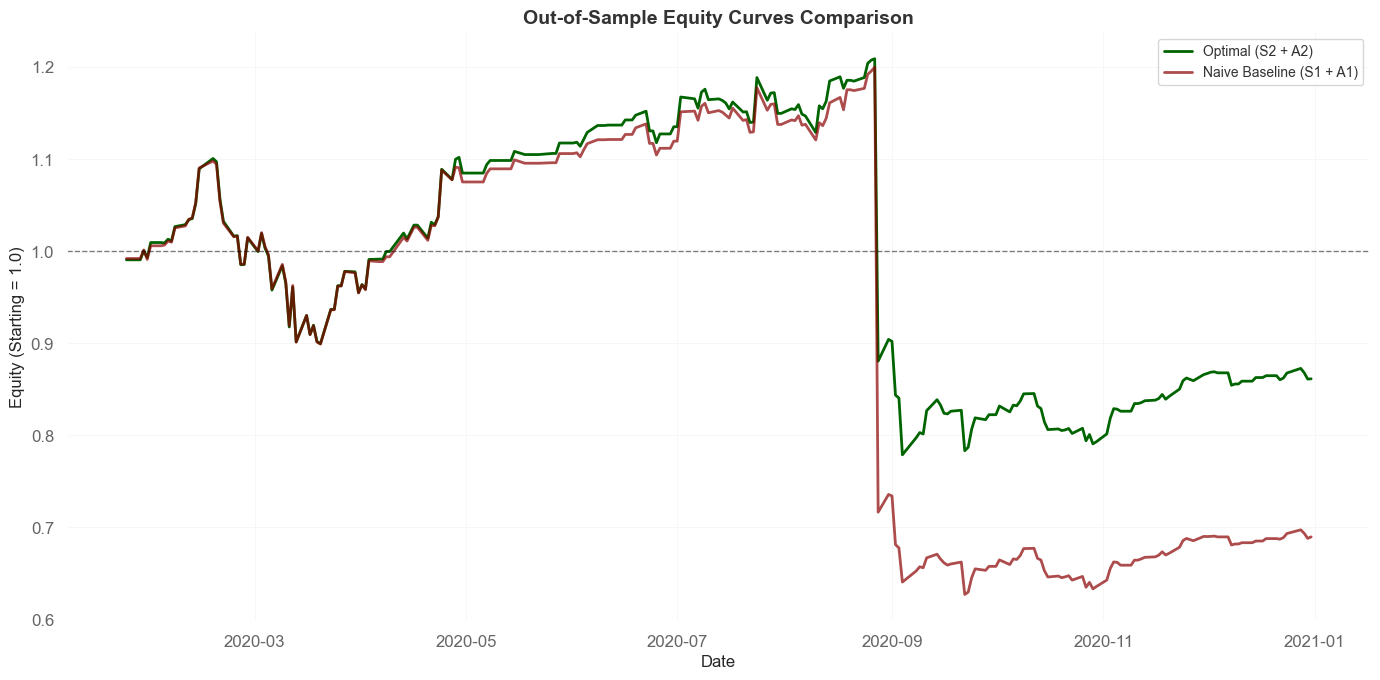

✅ Equity curve plotted

📊 Generating Returns Distribution Comparison...


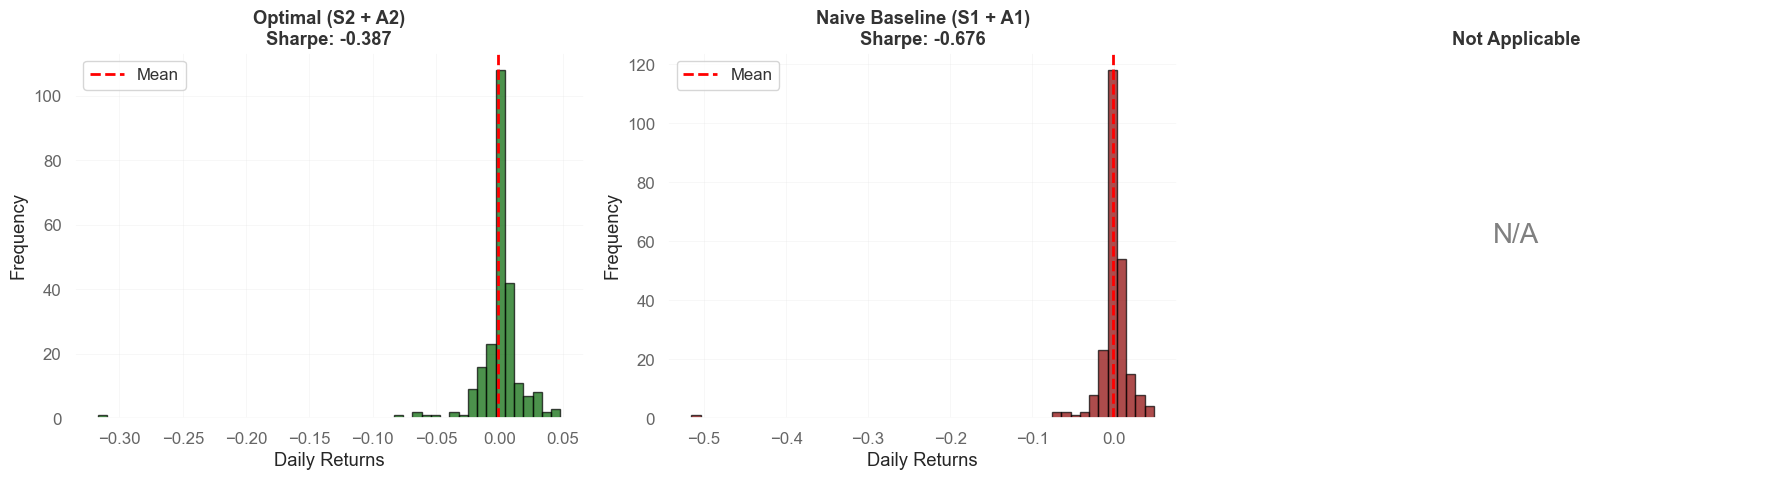

✅ Returns distributions plotted

📉 Generating Drawdown Analysis...


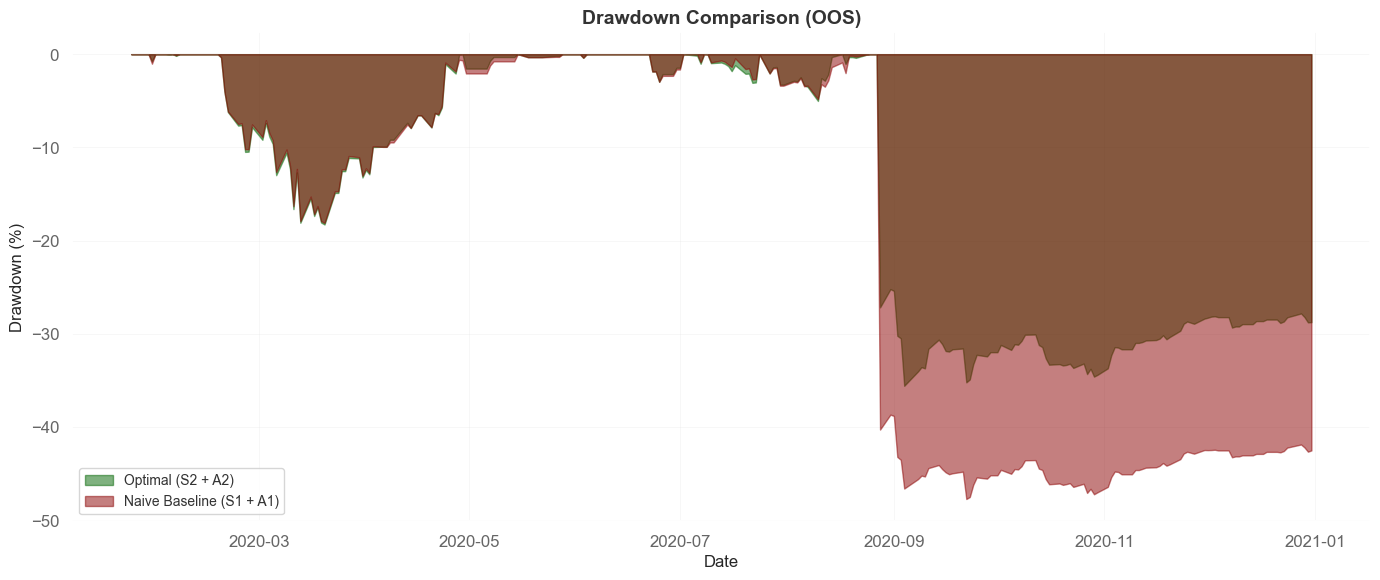

✅ Drawdown analysis plotted

📊 Generating Rolling Sharpe Ratio...


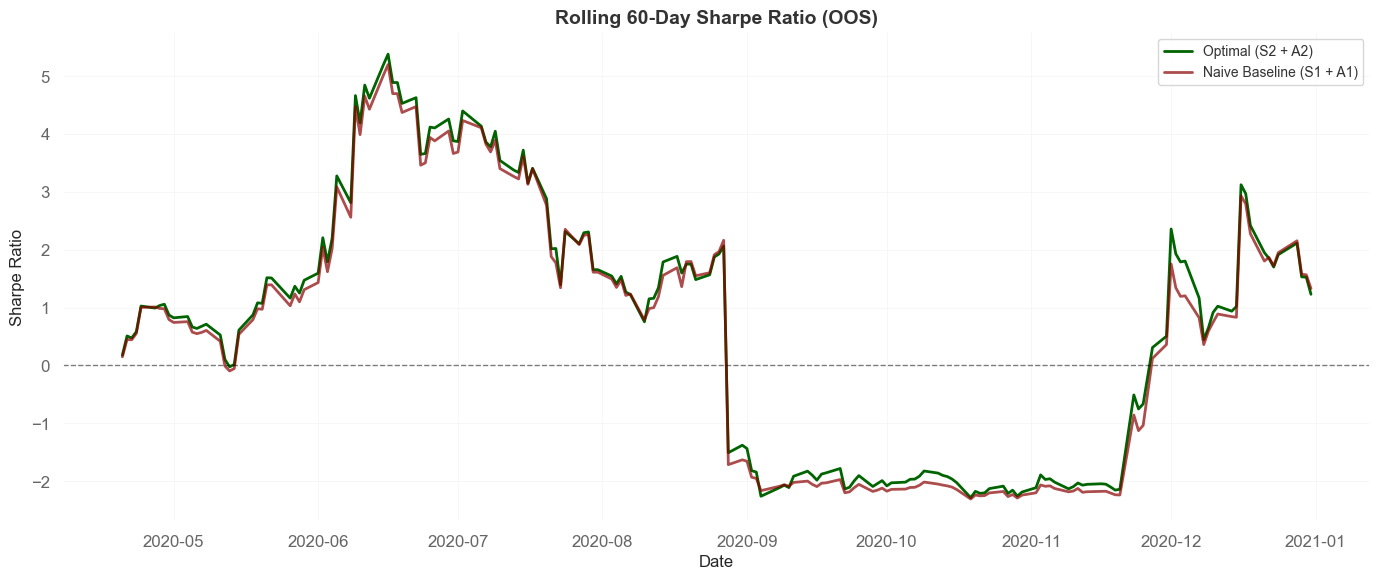

✅ Rolling Sharpe plotted

FINAL OOS EVALUATION SUMMARY

🎯 Optimal Strategy: Optimal (S2 + A2)
   Scoring Method:      S2
   Allocation Strategy: A2

📈 Performance Highlights:
   Total Return:        -13.86%
   Sharpe Ratio:       -0.3868
   Max Drawdown:        -35.58%
   Win Rate:             49.16%

📊 vs Baseline:
   Sharpe Ratio:  ✅ Better (-0.3868 vs -0.6761)
   Total Return:  ✅ Better (-13.86% vs -31.02%)
   Max Drawdown:  ✅ Better (-35.58% vs -47.72%)

🏆 Overall: 3/3 metrics improved
   ✅ Optimization SUCCESSFUL - Strategy shows improvement on OOS data!

💾 Results Available:
   - oos_result_optimal:  Main results for optimal strategy
   - oos_result_baseline: Baseline comparison
   - oos_df:              Full OOS DataFrame with all signals
   - comparison_df:       Performance comparison table

✅ Section 7 Complete! Ready for Section 8 (Output Generation)


In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 80)
print("VISUALIZATION & ANALYSIS")
print("=" * 80)

# ============================================================================
# 7.10: Equity Curve Comparison
# ============================================================================
print("\n📈 Generating Equity Curve Comparison...")

fig, ax = plt.subplots(figsize=(14, 7))

# Plot equity curves
ax.plot(result_optimal['equity'].index, result_optimal['equity'].values, 
        label=result_optimal['label'], linewidth=2, color='darkgreen')
ax.plot(result_baseline['equity'].index, result_baseline['equity'].values, 
        label=result_baseline['label'], linewidth=2, color='darkred', alpha=0.7)

if result_standard is not None:
    ax.plot(result_standard['equity'].index, result_standard['equity'].values, 
            label=result_standard['label'], linewidth=2, color='steelblue', alpha=0.7)

# Formatting
ax.set_title('Out-of-Sample Equity Curves Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Equity (Starting = 1.0)', fontsize=12)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

print("✅ Equity curve plotted")

# ============================================================================
# 7.11: Returns Distribution Comparison
# ============================================================================
print("\n📊 Generating Returns Distribution Comparison...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Optimal
axes[0].hist(result_optimal['returns'], bins=50, alpha=0.7, color='darkgreen', edgecolor='black')
axes[0].axvline(result_optimal['returns'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0].set_title(f"{result_optimal['label']}\nSharpe: {result_optimal['metrics']['sharpe']:.3f}", 
                  fontweight='bold')
axes[0].set_xlabel('Daily Returns')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Baseline
axes[1].hist(result_baseline['returns'], bins=50, alpha=0.7, color='darkred', edgecolor='black')
axes[1].axvline(result_baseline['returns'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1].set_title(f"{result_baseline['label']}\nSharpe: {result_baseline['metrics']['sharpe']:.3f}", 
                  fontweight='bold')
axes[1].set_xlabel('Daily Returns')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Standard (if available)
if result_standard is not None:
    axes[2].hist(result_standard['returns'], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    axes[2].axvline(result_standard['returns'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
    axes[2].set_title(f"{result_standard['label']}\nSharpe: {result_standard['metrics']['sharpe']:.3f}", 
                      fontweight='bold')
    axes[2].set_xlabel('Daily Returns')
    axes[2].set_ylabel('Frequency')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
else:
    axes[2].text(0.5, 0.5, 'N/A', ha='center', va='center', fontsize=20, color='gray')
    axes[2].set_title('Not Applicable', fontweight='bold')
    axes[2].axis('off')

plt.tight_layout()
plt.show()

print("✅ Returns distributions plotted")

# ============================================================================
# 7.12: Drawdown Analysis
# ============================================================================
print("\n📉 Generating Drawdown Analysis...")

def calculate_drawdown(equity):
    """Calculate drawdown series from equity curve"""
    running_max = equity.expanding().max()
    drawdown = (equity - running_max) / running_max
    return drawdown

fig, ax = plt.subplots(figsize=(14, 6))

# Calculate drawdowns
dd_optimal = calculate_drawdown(result_optimal['equity'])
dd_baseline = calculate_drawdown(result_baseline['equity'])

# Plot
ax.fill_between(dd_optimal.index, 0, dd_optimal.values * 100, 
                 alpha=0.5, color='darkgreen', label=result_optimal['label'])
ax.fill_between(dd_baseline.index, 0, dd_baseline.values * 100, 
                 alpha=0.5, color='darkred', label=result_baseline['label'])

if result_standard is not None:
    dd_standard = calculate_drawdown(result_standard['equity'])
    ax.fill_between(dd_standard.index, 0, dd_standard.values * 100, 
                     alpha=0.3, color='steelblue', label=result_standard['label'])

ax.set_title('Drawdown Comparison (OOS)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Drawdown (%)', fontsize=12)
ax.legend(loc='lower left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Drawdown analysis plotted")

# ============================================================================
# 7.13: Rolling Sharpe Ratio
# ============================================================================
print("\n📊 Generating Rolling Sharpe Ratio...")

def calculate_rolling_sharpe(returns, window=60):
    """Calculate rolling Sharpe ratio"""
    rolling_mean = returns.rolling(window=window).mean()
    rolling_std = returns.rolling(window=window).std()
    rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(252)
    return rolling_sharpe

fig, ax = plt.subplots(figsize=(14, 6))

# Calculate rolling Sharpe
rolling_window = 60  # 60 trading days ~ 3 months
rs_optimal = calculate_rolling_sharpe(result_optimal['returns'], rolling_window)
rs_baseline = calculate_rolling_sharpe(result_baseline['returns'], rolling_window)

# Plot
ax.plot(rs_optimal.index, rs_optimal.values, label=result_optimal['label'], 
        linewidth=2, color='darkgreen')
ax.plot(rs_baseline.index, rs_baseline.values, label=result_baseline['label'], 
        linewidth=2, color='darkred', alpha=0.7)

if result_standard is not None:
    rs_standard = calculate_rolling_sharpe(result_standard['returns'], rolling_window)
    ax.plot(rs_standard.index, rs_standard.values, label=result_standard['label'], 
            linewidth=2, color='steelblue', alpha=0.7)

ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_title(f'Rolling {rolling_window}-Day Sharpe Ratio (OOS)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Sharpe Ratio', fontsize=12)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Rolling Sharpe plotted")

# ============================================================================
# 7.14: Final Summary
# ============================================================================
print("\n" + "=" * 80)
print("FINAL OOS EVALUATION SUMMARY")
print("=" * 80)

print(f"\n🎯 Optimal Strategy: {result_optimal['label']}")
print(f"   Scoring Method:      {best_scoring}")
print(f"   Allocation Strategy: {best_allocation}")

print(f"\n📈 Performance Highlights:")
print(f"   Total Return:    {result_optimal['metrics']['total_return']:>10.2f}%")
print(f"   Sharpe Ratio:    {result_optimal['metrics']['sharpe']:>10.4f}")
print(f"   Max Drawdown:    {result_optimal['metrics']['max_drawdown']:>10.2f}%")
print(f"   Win Rate:        {result_optimal['metrics']['win_rate']:>10.2f}%")

print(f"\n📊 vs Baseline:")
optimal_better_sharpe = result_optimal['metrics']['sharpe'] > result_baseline['metrics']['sharpe']
optimal_better_return = result_optimal['metrics']['total_return'] > result_baseline['metrics']['total_return']
optimal_better_dd = result_optimal['metrics']['max_drawdown'] > result_baseline['metrics']['max_drawdown']

print(f"   Sharpe Ratio:  {'✅ Better' if optimal_better_sharpe else '❌ Worse'} "
      f"({result_optimal['metrics']['sharpe']:.4f} vs {result_baseline['metrics']['sharpe']:.4f})")
print(f"   Total Return:  {'✅ Better' if optimal_better_return else '❌ Worse'} "
      f"({result_optimal['metrics']['total_return']:.2f}% vs {result_baseline['metrics']['total_return']:.2f}%)")
print(f"   Max Drawdown:  {'✅ Better' if optimal_better_dd else '❌ Worse'} "
      f"({result_optimal['metrics']['max_drawdown']:.2f}% vs {result_baseline['metrics']['max_drawdown']:.2f}%)")

# Overall assessment
improvements = sum([optimal_better_sharpe, optimal_better_return, optimal_better_dd])
print(f"\n🏆 Overall: {improvements}/3 metrics improved")

if improvements >= 2:
    print(f"   ✅ Optimization SUCCESSFUL - Strategy shows improvement on OOS data!")
elif improvements == 1:
    print(f"   ⚠️  Optimization MIXED - Some improvement but not consistent")
else:
    print(f"   ❌ Optimization UNSUCCESSFUL - Strategy underperforms on OOS data")
    print(f"   💡 Consider: more regularization, simpler models, or ensemble approaches")

print(f"\n💾 Results Available:")
print(f"   - oos_result_optimal:  Main results for optimal strategy")
print(f"   - oos_result_baseline: Baseline comparison")
print(f"   - oos_df:              Full OOS DataFrame with all signals")
print(f"   - comparison_df:       Performance comparison table")

print(f"\n✅ Section 7 Complete! Ready for Section 8 (Output Generation)")



## 8. Output Generation

In [48]:
from src.helpers.output_generation import generate_oos_report
import os

print("=" * 80)
print("OUTPUT GENERATION: QuantStats HTML Reports")
print("=" * 80)

# ============================================================================
# Configuration
# ============================================================================
print("\n📊 Configuration:\n")

GENERATE_OPTIMAL_REPORT = True  # Main report (always recommended)
GENERATE_BASELINE_REPORT = False  # Baseline comparison (optional)
GENERATE_STANDARD_REPORT = False  # Standard approach (optional)
OUTPUT_DIR = "out"

print(f"  Reports to Generate:")
print(f"    Optimal Strategy:  {'✅ Yes' if GENERATE_OPTIMAL_REPORT else '❌ No'}")
print(f"    Baseline:          {'✅ Yes' if GENERATE_BASELINE_REPORT else '❌ No'}")
print(f"    Standard Approach: {'✅ Yes' if GENERATE_STANDARD_REPORT else '❌ No'}")
print(f"  Output Directory: {OUTPUT_DIR}/")

# ============================================================================
# Check Required Variables
# ============================================================================
print("\n" + "=" * 80)
print("Checking Required Variables")
print("=" * 80)

required_vars = {
    'oos_result_optimal': 'oos_result_optimal',
    'oos_df': 'oos_df',
    'dates_out_sample': 'dates_out_sample',
    'best_scoring': 'best_scoring',
    'best_allocation': 'best_allocation'
}

missing_vars = []
for var_name, display_name in required_vars.items():
    if var_name not in locals() and var_name not in globals():
        missing_vars.append(display_name)
        print(f"   ❌ Missing: {display_name}")
    else:
        print(f"   ✅ Found: {display_name}")

if missing_vars:
    print(f"\n⚠️  WARNING: Missing required variables: {', '.join(missing_vars)}")
    print(f"   Please run Section 7 first to generate OOS results.")
    raise ValueError("Missing required variables from Section 7")

print(f"\n✅ All required variables found!")

# ============================================================================
# Generate Report for Optimal Strategy
# ============================================================================
if GENERATE_OPTIMAL_REPORT:
    print("\n" + "=" * 80)
    print("🎯 Generating Report: Optimal Strategy")
    print("=" * 80)
    
    print(f"\nStrategy Details:")
    print(f"  Scoring Method:      {best_scoring}")
    print(f"  Allocation Strategy: {best_allocation}")
    print(f"  Performance:")
    print(f"    Total Return:    {oos_result_optimal['metrics']['total_return']:>10.2f}%")
    print(f"    Sharpe Ratio:    {oos_result_optimal['metrics']['sharpe']:>10.4f}")
    print(f"    Max Drawdown:    {oos_result_optimal['metrics']['max_drawdown']:>10.2f}%")
    
    # Generate report
    output_path_optimal = os.path.join(OUTPUT_DIR, "oos_optimal_tearsheet.html")
    report_title_optimal = (
        f"OUT-OF-SAMPLE: Optimal Strategy ({best_scoring} + {best_allocation})\n"
        f"Period: {dates_out_sample.min().date()} to {dates_out_sample.max().date()}"
    )
    
    generate_oos_report(
        portfolio_result=oos_result_optimal,
        oos_df=oos_df,
        dates_out_sample=dates_out_sample,
        output_path=output_path_optimal,
        report_title=report_title_optimal,
        output_dir=OUTPUT_DIR
    )
    
    print(f"\n✅ Optimal strategy report generated!")

# ============================================================================
# Generate Report for Baseline (Optional)
# ============================================================================
if GENERATE_BASELINE_REPORT:
    print("\n" + "=" * 80)
    print("📊 Generating Report: Baseline Strategy")
    print("=" * 80)
    
    if 'oos_result_baseline' not in locals() and 'oos_result_baseline' not in globals():
        print("   ⚠️  oos_result_baseline not found. Skipping baseline report.")
    else:
        print(f"\nStrategy Details:")
        print(f"  Scoring Method:      S1 (Simple Product)")
        print(f"  Allocation Strategy: A1 (Equal-Weighted)")
        print(f"  Performance:")
        print(f"    Total Return:    {oos_result_baseline['metrics']['total_return']:>10.2f}%")
        print(f"    Sharpe Ratio:    {oos_result_baseline['metrics']['sharpe']:>10.4f}")
        print(f"    Max Drawdown:    {oos_result_baseline['metrics']['max_drawdown']:>10.2f}%")
        
        # Generate report
        output_path_baseline = os.path.join(OUTPUT_DIR, "oos_baseline_tearsheet.html")
        report_title_baseline = (
            f"OUT-OF-SAMPLE: Baseline Strategy (S1 + A1)\n"
            f"Period: {dates_out_sample.min().date()} to {dates_out_sample.max().date()}"
        )
        
        generate_oos_report(
            portfolio_result=oos_result_baseline,
            oos_df=oos_df,
            dates_out_sample=dates_out_sample,
            output_path=output_path_baseline,
            report_title=report_title_baseline,
            output_dir=OUTPUT_DIR
        )
        
        print(f"\n✅ Baseline report generated!")

# ============================================================================
# Generate Report for Standard Approach (Optional)
# ============================================================================
if GENERATE_STANDARD_REPORT:
    print("\n" + "=" * 80)
    print("📊 Generating Report: Standard Approach")
    print("=" * 80)
    
    if 'oos_result_standard' not in locals() and 'oos_result_standard' not in globals():
        print("   ⚠️  oos_result_standard not found. Skipping standard report.")
    else:
        print(f"\nStrategy Details:")
        print(f"  Scoring Method:      S2 (Margin-Aware)")
        print(f"  Allocation Strategy: A2 (Rank-Weighted)")
        print(f"  Performance:")
        print(f"    Total Return:    {oos_result_standard['metrics']['total_return']:>10.2f}%")
        print(f"    Sharpe Ratio:    {oos_result_standard['metrics']['sharpe']:>10.4f}")
        print(f"    Max Drawdown:    {oos_result_standard['metrics']['max_drawdown']:>10.2f}%")
        
        # Generate report
        output_path_standard = os.path.join(OUTPUT_DIR, "oos_standard_tearsheet.html")
        report_title_standard = (
            f"OUT-OF-SAMPLE: Standard Approach (S2 + A2)\n"
            f"Period: {dates_out_sample.min().date()} to {dates_out_sample.max().date()}"
        )
        
        generate_oos_report(
            portfolio_result=oos_result_standard,
            oos_df=oos_df,
            dates_out_sample=dates_out_sample,
            output_path=output_path_standard,
            report_title=report_title_standard,
            output_dir=OUTPUT_DIR
        )
        
        print(f"\n✅ Standard approach report generated!")

# ============================================================================
# Final Summary
# ============================================================================
print("\n" + "=" * 80)
print("SUMMARY: Output Generation Complete")
print("=" * 80)

print(f"\n📁 Output Directory: {OUTPUT_DIR}/")
print(f"\n📄 Reports Generated:")

reports_generated = []
if GENERATE_OPTIMAL_REPORT:
    reports_generated.append(("oos_optimal_tearsheet.html", "Optimal Strategy", best_scoring, best_allocation))
if GENERATE_BASELINE_REPORT and 'oos_result_baseline' in locals() or 'oos_result_baseline' in globals():
    reports_generated.append(("oos_baseline_tearsheet.html", "Baseline", "S1", "A1"))
if GENERATE_STANDARD_REPORT and 'oos_result_standard' in locals() or 'oos_result_standard' in globals():
    reports_generated.append(("oos_standard_tearsheet.html", "Standard", "S2", "A2"))

for i, (filename, label, scoring, allocation) in enumerate(reports_generated, 1):
    full_path = os.path.join(OUTPUT_DIR, filename)
    file_exists = os.path.exists(full_path)
    status = "✅" if file_exists else "❌"
    print(f"\n{i}. {status} {filename}")
    print(f"   Label: {label}")
    print(f"   Strategy: {scoring} + {allocation}")
    if file_exists:
        file_size = os.path.getsize(full_path) / 1024  # KB
        print(f"   Size: {file_size:.1f} KB")

if not reports_generated:
    print("\n   ⚠️  No reports were generated. Check configuration flags.")

print(f"\n🎉 Output Generation Complete!")
print(f"\n💡 Next Steps:")
print(f"   1. Open the HTML reports in your browser")
print(f"   2. Review the QuantStats metrics and charts")
print(f"   3. Compare optimal vs baseline performance")
print(f"   4. Document your findings")

print(f"\n📊 To view reports:")
print(f"   - Windows: start {os.path.join(OUTPUT_DIR, 'oos_optimal_tearsheet.html')}")
print(f"   - Mac/Linux: open {os.path.join(OUTPUT_DIR, 'oos_optimal_tearsheet.html')}")

print(f"\n✅ All Done! Your portfolio backtesting project is complete! 🎯")



OUTPUT GENERATION: QuantStats HTML Reports

📊 Configuration:

  Reports to Generate:
    Optimal Strategy:  ✅ Yes
    Baseline:          ❌ No
    Standard Approach: ❌ No
  Output Directory: out/

Checking Required Variables
   ✅ Found: oos_result_optimal
   ✅ Found: oos_df
   ✅ Found: dates_out_sample
   ✅ Found: best_scoring
   ✅ Found: best_allocation

✅ All required variables found!

🎯 Generating Report: Optimal Strategy

Strategy Details:
  Scoring Method:      S2
  Allocation Strategy: A2
  Performance:
    Total Return:        -13.86%
    Sharpe Ratio:       -0.3868
    Max Drawdown:        -35.58%
Generating Out-Of-Sample HTML Report
    Saved: out\oos_optimal_tearsheet.html
   Period: 2020-01-27 to 2020-12-31
   Days:   237

✅ Optimal strategy report generated!

SUMMARY: Output Generation Complete

📁 Output Directory: out/

📄 Reports Generated:

1. ✅ oos_optimal_tearsheet.html
   Label: Optimal Strategy
   Strategy: S2 + A2
   Size: 519.2 KB

2. ❌ oos_baseline_tearsheet.html
  